# Sigap.ai - Fine-Tuned IndoBERT for Sentiment Analysis

Notebook ini disusun untuk proyek capstone IBM SkillsBuild Sigap.ai sebagai pipeline penelitian yang siap dijalankan di Google Colab GPU.

Scope notebook ini dibatasi secara tegas pada dataset final yang sudah selesai melalui seluruh tahap sebelumnya:
- data collection
- data cleaning
- data labeling
- data balancing
- data splitting
- data preprocessing

Eksperimen hanya menggunakan:
- feature: `Review_Text`
- target: `Sentiment_Label`

Model utama:
- `indobenchmark/indobert-base-p1`

Notebook ini juga membandingkan hasil Fine-Tuned IndoBERT dengan:
- Logistic Regression
- Linear SVM

## SECTION 1 - Project Overview

### Tujuan eksperimen
Tujuan eksperimen ini adalah membangun model final untuk sentiment analysis pada review UMKM Indonesia dengan pendekatan contextual language model. IndoBERT dipilih karena diharapkan menangkap konteks bahasa Indonesia yang lebih kaya dibanding pendekatan berbasis TF-IDF.

### Mengapa IndoBERT dipilih
IndoBERT merupakan model transformer bahasa Indonesia yang sudah dipra-latih pada korpus besar sehingga mampu memahami pola konteks, negasi, ambiguitas, dan variasi bahasa informal dengan lebih baik daripada model linear.

### Perbedaan TF-IDF dan Transformer
- TF-IDF merepresentasikan kata sebagai fitur sparse berbasis frekuensi.
- Transformer merepresentasikan teks sebagai contextual embedding yang berubah sesuai konteks kalimat.
- TF-IDF lebih ringan dan interpretabel, sedangkan transformer lebih kuat untuk konteks dan dependensi kata yang panjang.

### Keunggulan contextual embedding
Contextual embedding memungkinkan kata yang sama memiliki representasi berbeda tergantung kalimatnya. Ini penting untuk sentimen karena kata seperti "bagus" dapat bermakna berbeda ketika muncul bersama negasi, sarcasm, atau konteks keluhan.

## SECTION 2 - Environment Setup

Environment disiapkan untuk Google Colab GPU.
Package yang digunakan:
- transformers
- datasets
- evaluate
- accelerate
- torch
- scikit-learn
- lime
- seaborn

In [ ]:
!pip -q install transformers datasets evaluate accelerate torch scikit-learn lime seaborn joblib

In [ ]:
import os

os.environ["TRANSFORMERS_NO_TORCHVISION"] = "1"
os.environ["DISABLE_TORCHVISION_IMPORT"] = "1"

import gc
import re
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import evaluate
import joblib

from torch.optim import AdamW
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    TrainerCallback,
    EarlyStoppingCallback,
    get_cosine_schedule_with_warmup,
    set_seed,
)
from transformers.modeling_outputs import SequenceClassifierOutput
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from lime.lime_text import LimeTextExplainer
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 11
pd.set_option("display.max_colwidth", 250)
pd.set_option("display.max_columns", 100)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

from google.colab import drive
drive.mount('/content/drive')

Device: cuda
Mounted at /content/drive


## SECTION 3 - Load Dataset

Notebook ini mencari file dataset secara otomatis agar fleksibel dijalankan di Google Colab maupun workspace lokal.

File yang didukung:
- `df_train_final.csv` atau `train_final.csv`
- `df_validation_final.csv` atau `validation_final.csv`
- `df_test_final.csv` atau `test_final.csv`

In [ ]:
df_check = pd.read_csv(Path.cwd() / "train.csv", encoding="utf-8-sig")
print("Kolom:", df_check.columns.tolist())
print("\nLabel unik:", df_check["Sentiment_Label"].unique())
print("\nDistribusi raw:")
print(df_check["Sentiment_Label"].value_counts())

Kolom: ['Review_Text', 'Review_Text_Processed', 'Review_Date', 'Rating_Score', 'Business_Category', 'Sentiment_Label', 'Review_Aspect', 'Crisis_Flag', 'Is_Sarcasm']

Label unik: ['Positive' 'Netral' 'Negative']

Distribusi raw:
Sentiment_Label
Negative    12499
Netral      12493
Positive    12399
Name: count, dtype: int64


In [ ]:
# ============================================================
# SECTION 3 - Load Dataset, Validate, Preprocess, Augmentasi
# ============================================================

PROJECT_ROOT = Path.cwd()
TRAIN_PATH = PROJECT_ROOT / "train.csv"
VAL_PATH   = PROJECT_ROOT / "validation.csv"
TEST_PATH  = PROJECT_ROOT / "test.csv"

# ----------------------------------------------------------
# 3A. Standardize & Validate Labels
# ----------------------------------------------------------
LABEL_NORM_MAP = {
    "netral":   "Neutral",
    "Netral":   "Neutral",
    "neutral":  "Neutral",
    "NEUTRAL":  "Neutral",
    "positive": "Positive",
    "POSITIVE": "Positive",
    "POS":      "Positive",
    "pos":      "Positive",
    "negative": "Negative",
    "NEGATIVE": "Negative",
    "NEG":      "Negative",
    "neg":      "Negative",
    "Positif":  "Positive",
    "positif":  "Positive",
    "Negatif":  "Negative",
    "negatif":  "Negative",
}
VALID_LABELS = {"Positive", "Neutral", "Negative"}

def validate_and_clean(df, split_name):
    before = len(df)

    # Normalisasi label
    df["Sentiment_Label"] = (
        df["Sentiment_Label"]
        .astype(str)
        .str.strip()
        .replace(LABEL_NORM_MAP)
    )

    # Buang label tidak valid
    invalid_mask = ~df["Sentiment_Label"].isin(VALID_LABELS)
    if invalid_mask.sum() > 0:
        print(f"  [WARN] {split_name}: {invalid_mask.sum()} baris label invalid dibuang:")
        print(f"         {df.loc[invalid_mask, 'Sentiment_Label'].value_counts().to_dict()}")
    df = df[~invalid_mask].copy()

    # Buang Review_Text kosong / terlalu pendek
    df = df[df["Review_Text"].notna()].copy()
    df = df[df["Review_Text"].astype(str).str.strip().str.len() > 3].copy()

    # Buang duplikat exact
    before_dedup = len(df)
    df = df.drop_duplicates(subset=["Review_Text", "Sentiment_Label"]).copy()
    duped = before_dedup - len(df)
    if duped > 0:
        print(f"  [INFO] {split_name}: {duped} duplikat dihapus")

    df = df.reset_index(drop=True)
    print(f"  {split_name}: {before} → {len(df)} baris")
    return df


def load_split(path):
    df = pd.read_csv(path, encoding="utf-8-sig")
    required = ["Review_Text", "Sentiment_Label"]
    optional_defaults = {
        "Review_Text_Processed": None,
        "Rating_Score":          0,
        "Business_Category":     "Lainnya",
        "Review_Aspect":         "Lainnya",
        "Crisis_Flag":           "No",
        "Is_Sarcasm":            "No",
    }
    missing_req = [c for c in required if c not in df.columns]
    if missing_req:
        raise ValueError(f"{path.name} missing required columns: {missing_req}")
    for col, default in optional_defaults.items():
        if col not in df.columns:
            df[col] = default
    # Fallback: jika Review_Text_Processed kosong/semua NaN, pakai Review_Text
    if df["Review_Text_Processed"].isna().all():
        df["Review_Text_Processed"] = df["Review_Text"]
    df["Review_Text_Processed"] = df["Review_Text_Processed"].fillna(df["Review_Text"])
    return df


print("Loading datasets...")
train_df = validate_and_clean(load_split(TRAIN_PATH), "Train")
val_df   = validate_and_clean(load_split(VAL_PATH),   "Validation")
test_df  = validate_and_clean(load_split(TEST_PATH),  "Test")

for split_name, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"\n{split_name} shape: {df.shape}")
    print("Label distribution:")
    display(df["Sentiment_Label"].value_counts().to_frame("count"))
    print("Sample:")
    display(df[["Review_Text", "Sentiment_Label"]].head(3))


# ----------------------------------------------------------
# 3B. Text Preprocessing: Slang + Noise Cleaning
# ----------------------------------------------------------

# Noise cleaning khusus untuk data mentah seperti sample CSV di atas
def clean_noise(text):
    text = str(text)
    # Hapus mention Twitter (@username)
    text = re.sub(r'@\w+', '', text)
    # Hapus URL
    text = re.sub(r'http\S+|www\S+', '', text)
    # Hapus tanda kutip berulang (artefak CSV)
    text = re.sub(r'"{2,}', '"', text)
    # Hapus karakter non-ASCII berlebih (emoji, dsb) tapi pertahankan huruf+angka+tanda baca dasar
    text = re.sub(r'[^\w\s.,!?;:()\-\'\"/@]', ' ', text)
    # Normalisasi spasi
    text = re.sub(r'\s{2,}', ' ', text)
    return text.strip()


SLANG_MAP = {
    # Pronoun
    "gw": "saya", "gue": "saya", "lo": "kamu", "lu": "kamu", "sy": "saya",
    # Negasi
    "ga": "tidak", "gak": "tidak", "nggak": "tidak", "ngga": "tidak",
    "gausah": "tidak perlu", "gausa": "tidak perlu", "tak": "tidak",
    # Kata umum
    "aja": "saja", "doang": "saja", "cmn": "hanya", "cuma": "hanya",
    "udah": "sudah", "udh": "sudah", "sdh": "sudah",
    "blm": "belum", "hrs": "harus", "msh": "masih",
    "utk": "untuk", "dr": "dari", "pd": "pada",
    "bs": "bisa", "bisa": "dapat",
    "bgt": "sangat", "banget": "sangat",
    "bener": "benar", "emang": "memang",
    "kayak": "seperti", "kaya": "seperti",
    "tp": "tapi", "tapi": "tetapi",
    "krn": "karena", "karna": "karena",
    "yg": "yang", "dg": "dengan", "dgn": "dengan", "jg": "juga",
    # Kata sifat informal
    "oke": "baik", "ok": "baik", "sip": "baik", "mantap": "sangat baik",
    "mantul": "sangat baik", "josss": "sangat baik", "joss": "bagus",
    "anjir": "", "anjay": "", "waduh": "",
    # Filler / noise
    "wkwk": "", "wkwkwk": "", "haha": "", "hehe": "", "xixi": "",
    "hehehe": "", "hihi": "", "hahahaha": "",
}

def normalize_slang(text):
    words = str(text).split()
    result = [SLANG_MAP.get(w.lower(), w) for w in words]
    return " ".join([w for w in result if w]).strip()


# Negation handling — HANYA untuk Review_Text_Processed (dipakai TF-IDF baseline)
# Review_Text dibiarkan natural agar IndoBERT bisa baca konteks aslinya
def apply_negation(text):
    patterns = [
        (r"tidak\s+(\w+)", r"tidak_\1"),
        (r"bukan\s+(\w+)",  r"bukan_\1"),
        (r"belum\s+(\w+)",  r"belum_\1"),
        (r"jangan\s+(\w+)", r"jangan_\1"),
        (r"tak\s+(\w+)",    r"tak_\1"),
    ]
    for pat, rep in patterns:
        text = re.sub(pat, rep, str(text))
    return text


def detect_language_mix(text):
    EN_WORDS = {
        "good","bad","great","nice","worst","best","love","hate",
        "recommended","delicious","slow","fast","clean","dirty","fresh",
        "cold","hot","food","service","place","staff","order","delivery",
        "taste","price","quality","friendly","disappointed","satisfied",
        "excellent","terrible","awesome","ok","okay","very","so","not",
    }
    words = str(text).lower().split()
    en_count = sum(1 for w in words if w in EN_WORDS)
    return en_count >= 2


# Apply ke semua split
for df in [train_df, val_df, test_df]:
    # Bersihkan noise dulu dari teks asli
    df["Review_Text"]           = df["Review_Text"].apply(clean_noise)
    df["Review_Text"]           = df["Review_Text"].apply(normalize_slang)
    # Review_Text_Processed: slang + negation (untuk TF-IDF baseline)
    df["Review_Text_Processed"] = df["Review_Text_Processed"].apply(clean_noise)
    df["Review_Text_Processed"] = df["Review_Text_Processed"].apply(normalize_slang)
    df["Review_Text_Processed"] = df["Review_Text_Processed"].apply(apply_negation)
    df["is_mixed_lang"]         = df["Review_Text"].apply(detect_language_mix)

print("Preprocessing selesai")
print("Mixed language (train):", train_df["is_mixed_lang"].sum())

Loading datasets...
  [INFO] Train: 1163 duplikat dihapus
  Train: 37391 → 36228 baris
  [INFO] Validation: 55 duplikat dihapus
  Validation: 8025 → 7970 baris
  [INFO] Test: 68 duplikat dihapus
  Test: 8024 → 7956 baris

Train shape: (36228, 9)
Label distribution:


,count
Sentiment_Label,
Negative,12484
Positive,12250
Neutral,11494


Sample:


,Review_Text,Sentiment_Label
0,"Terimakasih.. Packing aman, barang baru dan bagus",Positive
1,aplikasi baru bikin ribet pesanan sudah siap bahkan 200% malah skor performa 20 aneh nih apliksi,Neutral
2,@draftanakunpad3 cobain fore deh matchanya lebih berasa (pesen less sugar wktu itu rasanya pas ga kebanyakan susu/cream,Neutral



Validation shape: (7970, 9)
Label distribution:


...


Test shape: (7956, 9)
Label distribution:


,count
Sentiment_Label,
Negative,2680
Positive,2657
Neutral,2619


Sample:


,Review_Text,Sentiment_Label
0,this store maintains the kualitas & brand name of domino's. their burger pizza is great in rasa. its perfect balance of spices & the bland bread rasa. our order was delivered on time and in good condition. overall its a pengalaman baik.,Positive
1,Orderan nya kurang gacor sengdangkan Kouta ttp harus berlangsung,Neutral
2,"giving a 4 coz i had to take a different cake, not the one which i chose",Positive


Preprocessing selesai
Mixed language (train): 4019


In [ ]:
# ----------------------------------------------------------
# 3C. Augmentasi — Data sudah balanced, fokus ke robustness
# ----------------------------------------------------------
# Data sudah balanced ~12.4K per kelas, tidak perlu balancing.
# Augmentasi difokuskan ke:
# 1. Mixed language normalization (banyak review English)
# 2. Synonym untuk variasi kosakata
# 3. TIDAK ada augmentasi masif — cukup +10-15% dari total

SYNONYM_MAP = {
    "enak":      ["lezat", "nikmat", "sedap"],
    "lezat":     ["enak", "nikmat", "sedap"],
    "bagus":     ["baik", "berkualitas", "memuaskan"],
    "buruk":     ["jelek", "mengecewakan", "tidak memuaskan"],
    "lambat":    ["lama", "telat", "tidak tepat waktu"],
    "cepat":     ["sigap", "tepat waktu", "responsif"],
    "mahal":     ["kemahalan", "tidak terjangkau"],
    "murah":     ["terjangkau", "ekonomis"],
    "kotor":     ["jorok", "tidak bersih"],
    "bersih":    ["rapi", "higienis"],
    "ramah":     ["sopan", "menyenangkan", "baik hati"],
    "pelayanan": ["layanan", "servis"],
    "makanan":   ["hidangan", "sajian"],
    "kecewa":    ["mengecewakan", "tidak memuaskan"],
    "puas":      ["memuaskan", "sesuai ekspektasi"],
    "harga":     ["tarif", "biaya"],
    "rasa":      ["cita rasa"],
    "porsi":     ["ukuran", "takaran"],
}

EN_TO_ID = {
    "good": "bagus", "bad": "buruk", "great": "luar biasa",
    "nice": "bagus", "worst": "terburuk", "best": "terbaik",
    "love": "sangat suka", "hate": "sangat tidak suka",
    "recommended": "direkomendasikan", "delicious": "lezat",
    "slow": "lambat", "fast": "cepat", "clean": "bersih",
    "dirty": "kotor", "fresh": "segar", "cold": "dingin",
    "hot": "panas", "friendly": "ramah",
    "disappointed": "kecewa", "satisfied": "puas",
    "excellent": "luar biasa", "terrible": "sangat buruk",
    "awesome": "sangat bagus", "okay": "baik", "ok": "baik",
    "great": "luar biasa", "horrible": "sangat buruk",
    "amazing": "luar biasa", "perfect": "sempurna",
    "tasty": "lezat", "yummy": "enak",
}

def safe_synonym_replace(text, prob=0.20):
    words = str(text).split()
    new_words = []
    for w in words:
        key = w.lower()
        if key in SYNONYM_MAP and random.random() < prob:
            new_words.append(random.choice(SYNONYM_MAP[key]))
        else:
            new_words.append(w)
    return " ".join(new_words)

def indonesianize(text):
    words = str(text).split()
    return " ".join([EN_TO_ID.get(w.lower(), w) for w in words])


label_counts = train_df["Sentiment_Label"].value_counts()
print("Distribusi sebelum augmentasi:\n", label_counts)
print(f"Data sudah balanced — tidak perlu balancing augmentation")

augmented_parts = [train_df.copy()]

# Augmentasi 1: Indonesianize mixed language reviews (robustness)
# Data ini banyak — lihat sample dengan full English
mixed_lang = train_df[train_df["is_mixed_lang"] == True].copy()
if len(mixed_lang) > 0:
    # Ambil 30% dari mixed lang, indonesianize
    n = min(len(mixed_lang), int(len(mixed_lang) * 0.3))
    ml_aug = mixed_lang.sample(n, replace=False, random_state=SEED).copy()
    ml_aug["Review_Text"]           = ml_aug["Review_Text"].apply(indonesianize)
    ml_aug["Review_Text_Processed"] = ml_aug["Review_Text_Processed"].apply(indonesianize)
    augmented_parts.append(ml_aug)
    print(f"  Mixed lang indonesianize: +{n} sampel")

# Augmentasi 2: Synonym replace untuk Neutral saja
# Neutral paling ambiguous — tambah variasi kosakata sedikit
neutral_samples = train_df[train_df["Sentiment_Label"] == "Neutral"].copy()
if len(neutral_samples) > 0:
    n = min(len(neutral_samples), 1000)
    neu_aug = neutral_samples.sample(n, replace=False, random_state=SEED).copy()
    neu_aug["Review_Text"]           = neu_aug["Review_Text"].apply(lambda t: safe_synonym_replace(t, prob=0.15))
    neu_aug["Review_Text_Processed"] = neu_aug["Review_Text_Processed"].apply(lambda t: safe_synonym_replace(t, prob=0.15))
    augmented_parts.append(neu_aug)
    print(f"  Neutral synonym aug: +{n} sampel")

# TIDAK ada augmentasi lebih — data sudah cukup besar (37K)
# Augmentasi berlebih pada data balanced justru menurunkan akurasi

train_df = pd.concat(augmented_parts, ignore_index=True)
train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\nDistribusi setelah augmentasi:\n", train_df["Sentiment_Label"].value_counts())
print(f"Total train samples: {len(train_df)}")

Distribusi sebelum augmentasi:
 Sentiment_Label
Negative    12484
Positive    12250
Neutral     11494
Name: count, dtype: int64
Data sudah balanced — tidak perlu balancing augmentation
  Mixed lang indonesianize: +1205 sampel
  Neutral synonym aug: +1000 sampel

Distribusi setelah augmentasi:
 Sentiment_Label
Positive    12923
Neutral     12756
Negative    12754
Name: count, dtype: int64
Total train samples: 38433


## SECTION 4 - Label Encoding

Label pada dataset distandarkan menjadi:
- `Positive`
- `Neutral`
- `Negative`

Meskipun file asli memakai `Netral`, notebook ini mengonversinya ke `Neutral` agar konsisten secara akademik.

In [ ]:
assert set(train_df["Sentiment_Label"].unique()) == {"Negative", "Neutral", "Positive"}, \
    f"Label belum ternormalisasi! Masih ada: {train_df['Sentiment_Label'].unique()}"
assert set(val_df["Sentiment_Label"].unique())   == {"Negative", "Neutral", "Positive"}, \
    f"Val label belum ternormalisasi! Masih ada: {val_df['Sentiment_Label'].unique()}"
assert set(test_df["Sentiment_Label"].unique())  == {"Negative", "Neutral", "Positive"}, \
    f"Test label belum ternormalisasi! Masih ada: {test_df['Sentiment_Label'].unique()}"

print("✓ Semua label sudah ternormalisasi")

✓ Semua label sudah ternormalisasi


In [ ]:
label_order = ["Negative", "Neutral", "Positive"]

label_encoder = LabelEncoder()
label_encoder.fit(label_order)

label_mapping = {
    label: int(label_encoder.transform([label])[0])
    for label in label_encoder.classes_
}

inverse_label_mapping = {
    v: k for k, v in label_mapping.items()
}

train_df["label"] = label_encoder.transform(
    train_df["Sentiment_Label"]
)

val_df["label"] = label_encoder.transform(
    val_df["Sentiment_Label"]
)

test_df["label"] = label_encoder.transform(
    test_df["Sentiment_Label"]
)

class_weights = None

print("Label mapping:", label_mapping)

Label mapping: {np.str_('Negative'): 0, np.str_('Neutral'): 1, np.str_('Positive'): 2}


## SECTION 5 - Dataset Preparation

Dataframe dikonversi ke HuggingFace Dataset agar compatible dengan pipeline fine-tuning transformer.

In [ ]:
# ============================================================
# SECTION 5 - Dataset Preparation
# ============================================================

def build_text(row):
    """
    Bangun input teks untuk IndoBERT.
    Prefix singkat dan informatif — jangan terlalu panjang
    agar tidak memakan token yang dibutuhkan untuk review asli.
    """
    category = str(row.get("Business_Category", "")).strip()
    aspect   = str(row.get("Review_Aspect",     "")).strip()
    crisis   = str(row.get("Crisis_Flag",       "")).strip()
    sarcasm  = str(row.get("Is_Sarcasm",        "")).strip()
    is_mixed = row.get("is_mixed_lang", False)

    review_text = str(row["Review_Text"])
    word_count  = len(review_text.split())

    # Tag panjang ulasan — membantu model untuk ulasan sangat singkat
    if word_count <= 4:
        length_tag = "Ulasan sangat singkat."
    elif word_count <= 12:
        length_tag = "Ulasan singkat."
    else:
        length_tag = ""

    prefix_parts = []
    if category and category not in ("nan", "Unknown", "Lainnya"):
        prefix_parts.append(f"[{category}]")
    if aspect and aspect not in ("nan", "Unknown", "Lainnya"):
        prefix_parts.append(f"[{aspect}]")
    if crisis == "Yes":
        prefix_parts.append("[Krisis]")
    if sarcasm == "Yes":
        prefix_parts.append("[Sarkasme]")
    if is_mixed:
        prefix_parts.append("[Bilingual]")
    if length_tag:
        prefix_parts.append(length_tag)

    prefix = " ".join(prefix_parts)
    return f"{prefix} {review_text}".strip() if prefix else review_text


for df in [train_df, val_df, test_df]:
    df["text"] = df.apply(build_text, axis=1)

# Cek panjang token rata-rata untuk pilih max_length
sample_lengths = train_df["text"].apply(lambda t: len(t.split())).describe()
print("Distribusi panjang kata (approximate token count):")
print(sample_lengths)
print("\nContoh teks input:")
print(train_df["text"].iloc[0])
print(train_df["text"].iloc[1])

hf_dataset = DatasetDict({
    "train":      Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False),
    "validation": Dataset.from_pandas(val_df[["text", "label"]],   preserve_index=False),
    "test":       Dataset.from_pandas(test_df[["text", "label"]],   preserve_index=False),
})
train_dataset      = hf_dataset["train"]
validation_dataset = hf_dataset["validation"]
test_dataset       = hf_dataset["test"]
display(hf_dataset)

Distribusi panjang kata (approximate token count):
count    38433.000000
mean        29.975230
std         33.138337
min          4.000000
25%         13.000000
50%         21.000000
75%         37.000000
max        989.000000
Name: text, dtype: float64

Contoh teks input:
[F&B] [Rasa] Ulasan singkat. Pelayanan yTiwi bagus ramah serta mknan y enak
[F&B] [Rasa] Ulasan sangat singkat. sippp ok...rasa enak


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 38433
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 7970
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7956
    })
})

## SECTION 6 - Tokenization

Tokenizer yang digunakan:
- `AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")`

Eksperimen tokenisasi:
- `max_length = 128`
- `max_length = 256`

Seluruh tokenisasi menggunakan:
- `truncation=True`
- `padding="max_length"`

In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "indobenchmark/indobert-large-p2"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True
)

id2label = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

label2id = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocab size: {tokenizer.vocab_size}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded: indobenchmark/indobert-large-p2
Vocab size: 30521


## SECTION 7 - Model Preparation

Model yang digunakan adalah `AutoModelForSequenceClassification` dengan `num_labels = 3`.
Bagian ini juga menampilkan jumlah parameter model agar kebutuhan komputasi jelas sejak awal.

In [ ]:
# ============================================================
# SECTION 7 - Model Preparation
# ============================================================

import torch.nn as nn
from transformers import AutoModelForSequenceClassification
from transformers.modeling_outputs import SequenceClassifierOutput


class SentimentFineTunedModel(nn.Module):
    def __init__(self, model_name, num_labels, id2label, label2id):
        super().__init__()

        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=num_labels,
            id2label=id2label,
            label2id=label2id,
            ignore_mismatched_sizes=True,
        )

        self.config = self.model.config
        self.num_labels = num_labels

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        token_type_ids=None,
        labels=None,
        **kwargs
    ):
        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            labels=labels,
        )

        return SequenceClassifierOutput(
            loss=outputs.loss,
            logits=outputs.logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
        )


def create_model():

    model = SentimentFineTunedModel(
        model_name=MODEL_NAME,
        num_labels=3,
        id2label=id2label,
        label2id=label2id,
    )

    model.model.gradient_checkpointing_enable()

    total_params = sum(
        p.numel() for p in model.parameters()
    )

    trainable_params = sum(
        p.numel() for p in model.parameters()
        if p.requires_grad
    )

    print(f"Model                : {MODEL_NAME}")
    print(f"Total parameters     : {total_params:,}")
    print(f"Trainable parameters : {trainable_params:,}")

    return model

## SECTION 8 - Training Configuration

Hyperparameter eksperimen:
- Learning Rate: `2e-5`, `3e-5`, `5e-5`
- Batch Size: `8`, `16`
- Epoch: `3`, `5`, `7`

Training menggunakan:
- weight decay
- warmup
- early stopping
- best model checkpoint

Metric utama:
- `F1 Macro`

Untuk menjaga runtime tetap realistis, notebook memakai pendekatan staged tuning:
1. Bandingkan `max_length` 128 vs 256
2. Tuning learning rate
3. Tuning batch size
4. Tuning epoch

In [ ]:
accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

# ============================================================
# SECTION 8 - Training Configuration
# ============================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":        accuracy_score(labels, preds),
        "precision_macro": precision_score(labels, preds, average="macro", zero_division=0),
        "recall_macro":    recall_score(labels,    preds, average="macro", zero_division=0),
        "f1_macro":        f1_score(labels,        preds, average="macro", zero_division=0),
        "f1_neutral":      f1_score(labels,        preds, average=None,    zero_division=0)[label_mapping["Neutral"]],
    }


def prepare_dataset(max_length):
    def tok(dataset):
        return dataset.map(
            lambda batch: tokenizer(
                batch["text"],
                truncation=True,
                padding="max_length",
                max_length=max_length,
            ),
            batched=True,
            remove_columns=["text"],
        )
    dataset = DatasetDict({
        "train":      tok(train_dataset),
        "validation": tok(validation_dataset),
        "test":       tok(test_dataset),
    })
    for split in dataset.keys():
        dataset[split] = dataset[split].rename_column("label", "labels")
        dataset[split].set_format(type=None)
    return dataset


def build_training_args(run_dir, learning_rate, batch_size, epochs):
    return TrainingArguments(
        output_dir=run_dir,
        eval_strategy="steps",
        save_strategy="steps",
        eval_steps=100,
        save_steps=100,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        num_train_epochs=epochs,
        weight_decay=0.01,
        warmup_ratio=0.1,
        lr_scheduler_type="cosine",
        label_smoothing_factor=0.0,
        gradient_accumulation_steps=2,
        fp16=torch.cuda.is_available(),
        logging_steps=50,
        save_total_limit=2,
        report_to="none",
        dataloader_num_workers=2,      # BUG FIX: hapus baris typo sebelumnya
    )


# WeightedTrainer — definisi SATU KALI di sini, hapus versi lama di Section 4
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def create_optimizer(self):

        classifier_params = []
        backbone_params = []

        for name, param in self.model.named_parameters():

            if not param.requires_grad:
                continue

            if "classifier" in name:
                classifier_params.append(param)
            else:
                backbone_params.append(param)

        optimizer_grouped = [
            {
                "params": backbone_params,
                "lr": self.args.learning_rate
            },
            {
                "params": classifier_params,
                "lr": self.args.learning_rate * 2
            }
        ]

        self.optimizer = AdamW(
            optimizer_grouped,
            weight_decay=0.01
        )

        return self.optimizer

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        **kwargs
    ):

        labels = inputs.pop("labels")

        outputs = model(**inputs)

        logits = outputs.logits

        loss_fct = nn.CrossEntropyLoss()

        loss = loss_fct(
            logits.view(-1, self.model.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

def run_experiment(max_length, learning_rate, batch_size, epochs, tag):
    dataset = prepare_dataset(max_length)
    model = create_model()
    args = build_training_args(
        run_dir=f"./runs/{tag}",
        learning_rate=learning_rate,
        batch_size=batch_size,
        epochs=epochs,
    )
    trainer = WeightedTrainer(
        class_weights=class_weights,
        model=model,
        args=args,
        train_dataset=dataset["train"],
        eval_dataset=dataset["validation"],
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )
    train_result = trainer.train()
    val_metrics = trainer.evaluate(dataset["validation"])
    val_pred = trainer.predict(dataset["validation"])
    test_pred = trainer.predict(dataset["test"])
    result = {
        "tag": tag,
        "max_length": max_length,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "epochs": epochs,
        "trainer": trainer,
        "dataset": dataset,
        "train_result": train_result,
        "val_metrics": val_metrics,
        "val_predictions": np.argmax(val_pred.predictions, axis=-1),
        "val_labels": val_pred.label_ids,
        "val_logits": val_pred.predictions,
        "test_predictions": np.argmax(test_pred.predictions, axis=-1),
        "test_labels": test_pred.label_ids,
        "test_logits": test_pred.predictions,
        "log_history": trainer.state.log_history,
        "train_runtime": train_result.metrics.get("train_runtime", np.nan),
        "eval_runtime": val_metrics.get("eval_runtime", np.nan),
        "model": trainer.model,
    }
    return result

## SECTION 9 - Fine-Tuning

HuggingFace `Trainer` digunakan untuk fine-tuning dan logging.

Section ini menjalankan staged tuning agar eksperimen tetap terkontrol:
- tahap 1: max_length
- tahap 2: learning rate
- tahap 3: batch size
- tahap 4: epoch

In [ ]:
# experiment_results = []

# # Stage 1: max_length comparison
# base_lr = 1e-5
# base_batch = 16
# base_epochs = 5
# for max_len in [128, 256]:
#     tag = f"len{max_len}_lr{base_lr}_bs{base_batch}_ep{base_epochs}".replace(".", "")
#     result = run_experiment(max_len, base_lr, base_batch, base_epochs, tag)
#     experiment_results.append(result)
#     del result["trainer"]
#     gc.collect()
#     if torch.cuda.is_available():
#         torch.cuda.empty_cache()

# maxlen_table = pd.DataFrame([{
#     "max_length": r["max_length"],
#     "learning_rate": r["learning_rate"],
#     "batch_size": r["batch_size"],
#     "epochs": r["epochs"],
#     "accuracy": r["val_metrics"]["eval_accuracy"],
#     "precision": r["val_metrics"]["eval_precision_macro"],
#     "recall": r["val_metrics"]["eval_recall_macro"],
#     "f1": r["val_metrics"]["eval_f1_macro"],
# } for r in experiment_results]).sort_values("f1", ascending=False)
# display(maxlen_table)

In [ ]:
# best_max_length = int(maxlen_table.iloc[0]["max_length"])
# best_batch = int(maxlen_table.iloc[0]["batch_size"])
# best_epochs = int(maxlen_table.iloc[0]["epochs"])

# lr_results = []
# for lr in [1e-5, 2e-5, 3e-5]:
#     tag = f"len{best_max_length}_lr{lr}_bs{best_batch}_ep{best_epochs}".replace(".", "")
#     result = run_experiment(best_max_length, lr, best_batch, best_epochs, tag)
#     lr_results.append(result)
#     del result["trainer"]
#     gc.collect()
#     if torch.cuda.is_available():
#         torch.cuda.empty_cache()

# lr_table = pd.DataFrame([{
#     "learning_rate": r["learning_rate"],
#     "batch_size": r["batch_size"],
#     "epochs": r["epochs"],
#     "accuracy": r["val_metrics"]["eval_accuracy"],
#     "precision": r["val_metrics"]["eval_precision_macro"],
#     "recall": r["val_metrics"]["eval_recall_macro"],
#     "f1": r["val_metrics"]["eval_f1_macro"],
# } for r in lr_results]).sort_values("f1", ascending=False)
# display(lr_table)

In [ ]:
# best_lr = float(lr_table.iloc[0]["learning_rate"])
# batch_results = []
# for batch_size in [8, 16]:
#     tag = f"len{best_max_length}_lr{best_lr}_bs{batch_size}_ep{best_epochs}".replace(".", "")
#     result = run_experiment(best_max_length, best_lr, batch_size, best_epochs, tag)
#     batch_results.append(result)
#     del result["trainer"]
#     gc.collect()
#     if torch.cuda.is_available():
#         torch.cuda.empty_cache()

# batch_table = pd.DataFrame([{
#     "batch_size": r["batch_size"],
#     "learning_rate": r["learning_rate"],
#     "epochs": r["epochs"],
#     "accuracy": r["val_metrics"]["eval_accuracy"],
#     "precision": r["val_metrics"]["eval_precision_macro"],
#     "recall": r["val_metrics"]["eval_recall_macro"],
#     "f1": r["val_metrics"]["eval_f1_macro"],
# } for r in batch_results]).sort_values("f1", ascending=False)
# display(batch_table)

In [ ]:
# best_batch = int(batch_table.iloc[0]["batch_size"])
# epoch_results = []
# for epochs in [3, 5, 7]:
#     tag = f"len{best_max_length}_lr{best_lr}_bs{best_batch}_ep{epochs}".replace(".", "")
#     result = run_experiment(best_max_length, best_lr, best_batch, epochs, tag)
#     epoch_results.append(result)
#     del result["trainer"]
#     gc.collect()
#     if torch.cuda.is_available():
#         torch.cuda.empty_cache()

# epoch_table = pd.DataFrame([{
#     "epochs": r["epochs"],
#     "learning_rate": r["learning_rate"],
#     "batch_size": r["batch_size"],
#     "accuracy": r["val_metrics"]["eval_accuracy"],
#     "precision": r["val_metrics"]["eval_precision_macro"],
#     "recall": r["val_metrics"]["eval_recall_macro"],
#     "f1": r["val_metrics"]["eval_f1_macro"],
# } for r in epoch_results]).sort_values("f1", ascending=False)
# display(epoch_table)

# best_row = epoch_table.iloc[0]

# ============================================================
# SECTION 9 - Fine-Tuning
# ============================================================

BEST_CONFIG = {
    "max_length": 256,
    "learning_rate": 2e-5,
    "batch_size": 8,
    "epochs": 10,
}
print("BEST_CONFIG =", BEST_CONFIG)


class BestScoreCallback(TrainerCallback):
    def __init__(self):
        self.best_f1   = 0.0
        self.best_step = 0
        self.history   = []

    # BUG FIX: hapus baris corrupt "d f l t ( lf t t t l t i N **k )"
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        f1  = metrics.get("eval_f1_macro",  0.0)
        acc = metrics.get("eval_accuracy",   0.0)
        self.history.append({"step": state.global_step, "f1": f1, "acc": acc})
        if f1 > self.best_f1:
            self.best_f1   = f1
            self.best_step = state.global_step
            print(f"\n  New best F1: {f1:.4f} | Acc: {acc:.4f} @ step {state.global_step}")


best_score_cb = BestScoreCallback()

final_dataset = prepare_dataset(BEST_CONFIG["max_length"])
final_model   = create_model()
final_args    = build_training_args(
    run_dir       = "./runs/final_indobert",
    learning_rate = BEST_CONFIG["learning_rate"],
    batch_size    = BEST_CONFIG["batch_size"],
    epochs        = BEST_CONFIG["epochs"],
)

final_trainer = WeightedTrainer(
    class_weights = class_weights,
    model         = final_model,
    args          = final_args,
    train_dataset = final_dataset["train"],
    eval_dataset  = final_dataset["validation"],
    compute_metrics = compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=4),
        best_score_cb,
    ],
)

print("Memulai training...")
final_train_result = final_trainer.train()

print("\nEvaluasi validation set...")
final_val_metrics = final_trainer.evaluate(final_dataset["validation"])

print("\nPrediksi validation set...")
final_val_pred        = final_trainer.predict(final_dataset["validation"])
final_val_labels      = final_val_pred.label_ids
final_val_logits      = final_val_pred.predictions
final_val_predictions = np.argmax(final_val_logits, axis=-1)

print("\nPrediksi test set...")
final_test_pred        = final_trainer.predict(final_dataset["test"])
final_test_labels      = final_test_pred.label_ids
final_test_logits      = final_test_pred.predictions
final_test_predictions = np.argmax(final_test_logits, axis=-1)

final_log_history = pd.DataFrame(final_trainer.state.log_history)
display(final_log_history.tail(10))
print(f"\nBest F1 selama training: {best_score_cb.best_f1:.4f} @ step {best_score_cb.best_step}")


BEST_CONFIG = {'max_length': 256, 'learning_rate': 2e-05, 'batch_size': 8, 'epochs': 10}


Map:   0%|          | 0/38433 [00:00<?, ? examples/s]

Map:   0%|          | 0/7970 [00:00<?, ? examples/s]

Map:   0%|          | 0/7956 [00:00<?, ? examples/s]

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


...

Training Loss,Validation Loss,Step,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Neutral
0.801904,0.429186,3100,0.817315,0.825340,0.817646,0.817499,0.764727



Prediksi validation set...



Prediksi test set...


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision_macro,eval_recall_macro,eval_f1_macro,eval_f1_neutral,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
85,0.856033,12.886723,0.00002,1.206868,2900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
86,NaN,NaN,NaN,1.206868,2900,0.445247,0.816688,0.815259,0.816290,0.814537,0.738344,85.7791,92.913,5.817,NaN,NaN,NaN,NaN,NaN
87,0.680843,11.803337,0.00002,1.227680,2950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
88,0.828717,29.791864,0.00002,1.248491,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89,NaN,NaN,NaN,1.248491,3000,0.500889,0.796863,0.819857,0.797614,0.793297,0.752965,85.6625,93.039,5.825,NaN,NaN,NaN,NaN,NaN
90,0.776573,12.236211,0.00002,1.269303,3050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91,0.801904,26.175543,0.00002,1.290114,3100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92,NaN,NaN,NaN,1.290114,3100,0.458336,0.818193,0.821833,0.818408,0.817138,0.761922,85.7057,92.993,5.822,NaN,NaN,NaN,NaN,NaN
93,NaN,NaN,NaN,1.290114,3100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7508.1446,51.188,3.201,0.0,1.060879
94,NaN,NaN,NaN,1.290114,3100,0.429186,0.817315,0.825340,0.817646,0.817499,0.764727,85.9173,92.764,5.808,NaN,NaN,NaN,NaN,NaN



Best F1 selama training: 0.8175 @ step 2700


## SECTION 10 - Evaluation

Evaluasi dilakukan pada validation set dan test set dengan metrik:
- Accuracy
- Precision
- Recall
- F1 Score

Bagian ini juga menampilkan classification report lengkap.

In [ ]:
def build_metrics(y_true, y_pred, split_name):
    return {
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

val_metrics = build_metrics(final_val_labels, final_val_predictions, "validation")
test_metrics = build_metrics(final_test_labels, final_test_predictions, "test")
metrics_df = pd.DataFrame([val_metrics, test_metrics])
display(metrics_df)

val_report = classification_report(final_val_labels, final_val_predictions, target_names=label_encoder.classes_, output_dict=True, zero_division=0)
test_report = classification_report(final_test_labels, final_test_predictions, target_names=label_encoder.classes_, output_dict=True, zero_division=0)
val_report_df = pd.DataFrame(val_report).T.reset_index().rename(columns={"index": "label"})
test_report_df = pd.DataFrame(test_report).T.reset_index().rename(columns={"index": "label"})
display(val_report_df)
display(test_report_df)

print("Validation report:")
print(classification_report(final_val_labels, final_val_predictions, target_names=label_encoder.classes_, digits=4, zero_division=0))
print("Test report:")
print(classification_report(final_test_labels, final_test_predictions, target_names=label_encoder.classes_, digits=4, zero_division=0))

,split,accuracy,precision_macro,recall_macro,f1_macro
0,validation,0.817315,0.825340,0.817646,0.817499
1,test,0.817748,0.826159,0.818101,0.817701


,label,precision,recall,f1-score,support
0,Negative,0.867241,0.714179,0.783303,2680.000000
1,Neutral,0.710192,0.828333,0.764727,2633.000000
2,Positive,0.898588,0.910425,0.904468,2657.000000
3,accuracy,0.817315,0.817315,0.817315,0.817315
4,macro avg,0.825340,0.817646,0.817499,7970.000000
5,weighted avg,0.825808,0.817315,0.817559,7970.000000


,label,precision,recall,f1-score,support
0,Negative,0.875919,0.711194,0.785008,2680.000000
1,Neutral,0.708401,0.827415,0.763297,2619.000000
2,Positive,0.894157,0.915694,0.904797,2657.000000
3,accuracy,0.817748,0.817748,0.817748,0.817748
4,macro avg,0.826159,0.818101,0.817701,7956.000000
5,weighted avg,0.826865,0.817748,0.817866,7956.000000


Validation report:
              precision    recall  f1-score   support

    Negative     0.8672    0.7142    0.7833      2680
     Neutral     0.7102    0.8283    0.7647      2633
    Positive     0.8986    0.9104    0.9045      2657

    accuracy                         0.8173      7970
   macro avg     0.8253    0.8176    0.8175      7970
weighted avg     0.8258    0.8173    0.8176      7970

Test report:
              precision    recall  f1-score   support

    Negative     0.8759    0.7112    0.7850      2680
     Neutral     0.7084    0.8274    0.7633      2619
    Positive     0.8942    0.9157    0.9048      2657

    accuracy                         0.8177      7956
   macro avg     0.8262    0.8181    0.8177      7956
weighted avg     0.8269    0.8177    0.8179      7956



## SECTION 11 - Visualization

Visualisasi profesional yang siap dipakai pada slide presentasi capstone:
1. Training loss curve
2. Validation loss curve
3. Accuracy curve
4. F1 curve
5. Confusion matrix
6. Classification report heatmap
7. Prediction distribution

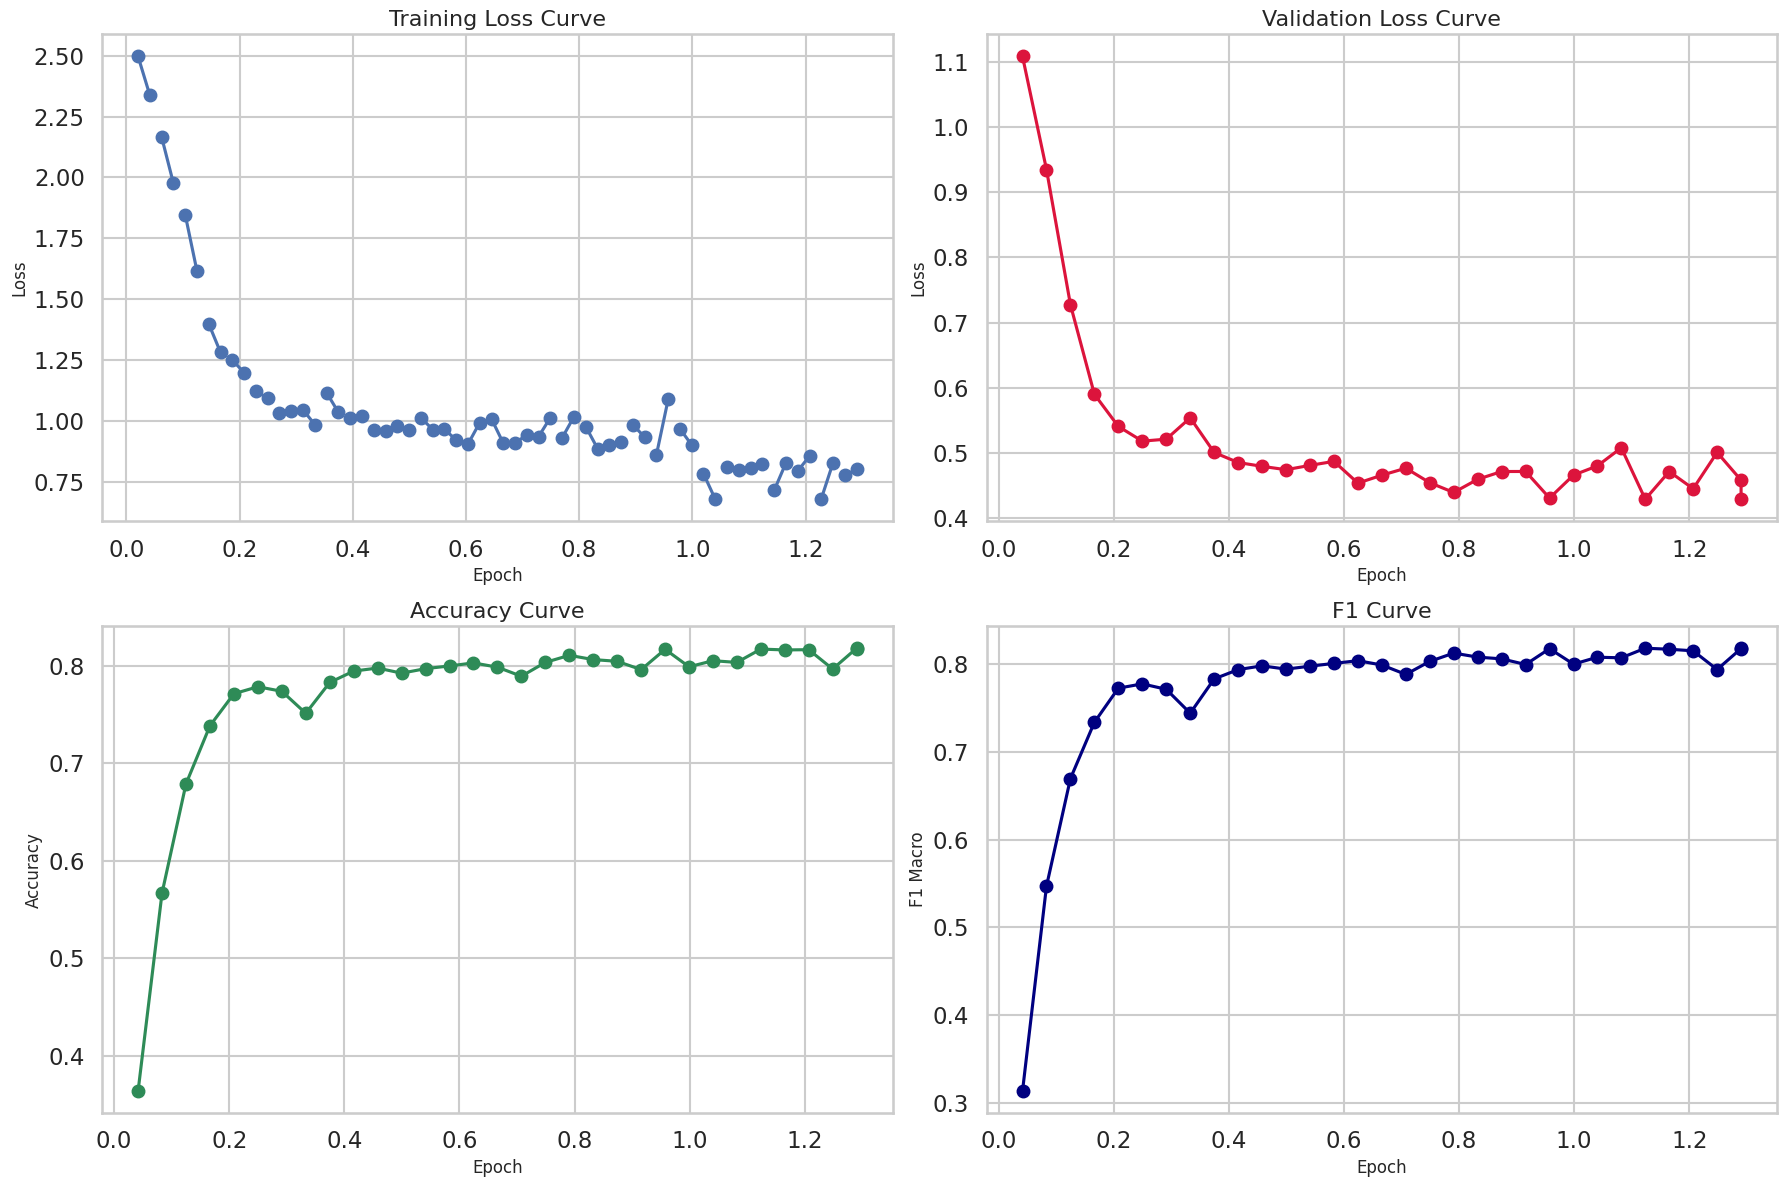

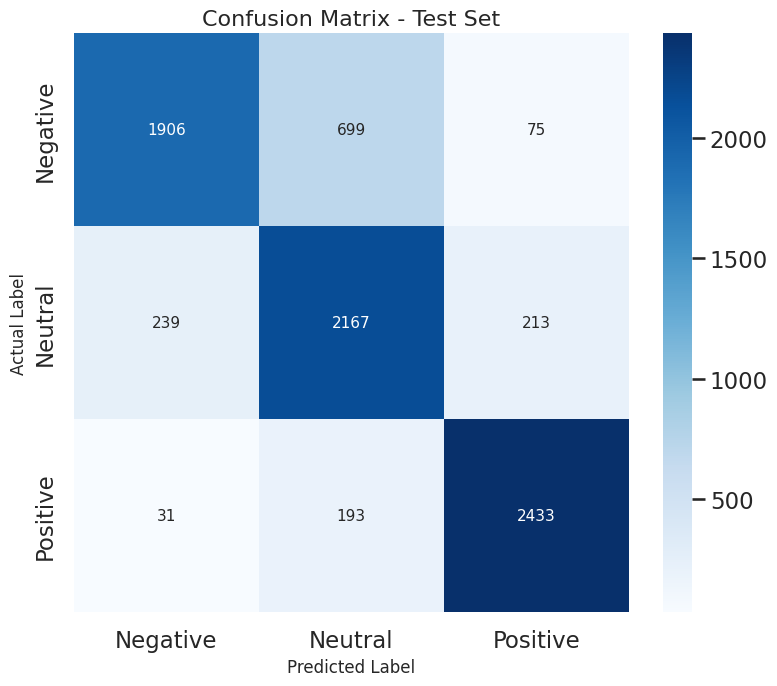

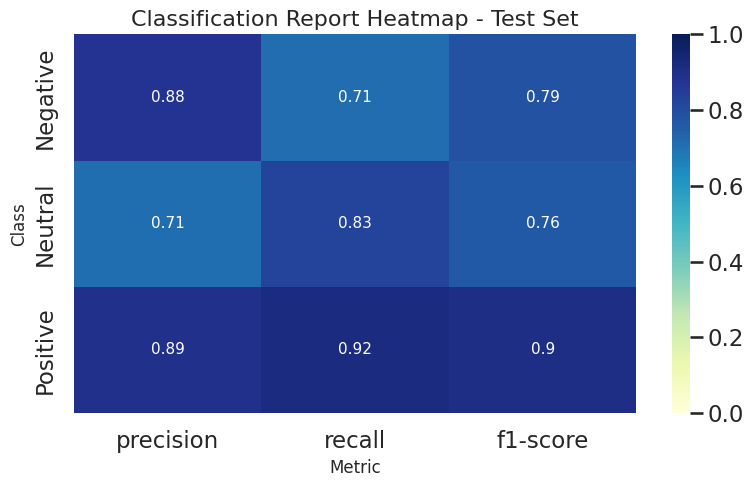

/tmp/ipykernel_1303/3026973823.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pred_dist.index, y=pred_dist.values, ax=axes[0], palette="viridis")
/tmp/ipykernel_1303/3026973823.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=actual_dist.index, y=actual_dist.values, ax=axes[1], palette="viridis")


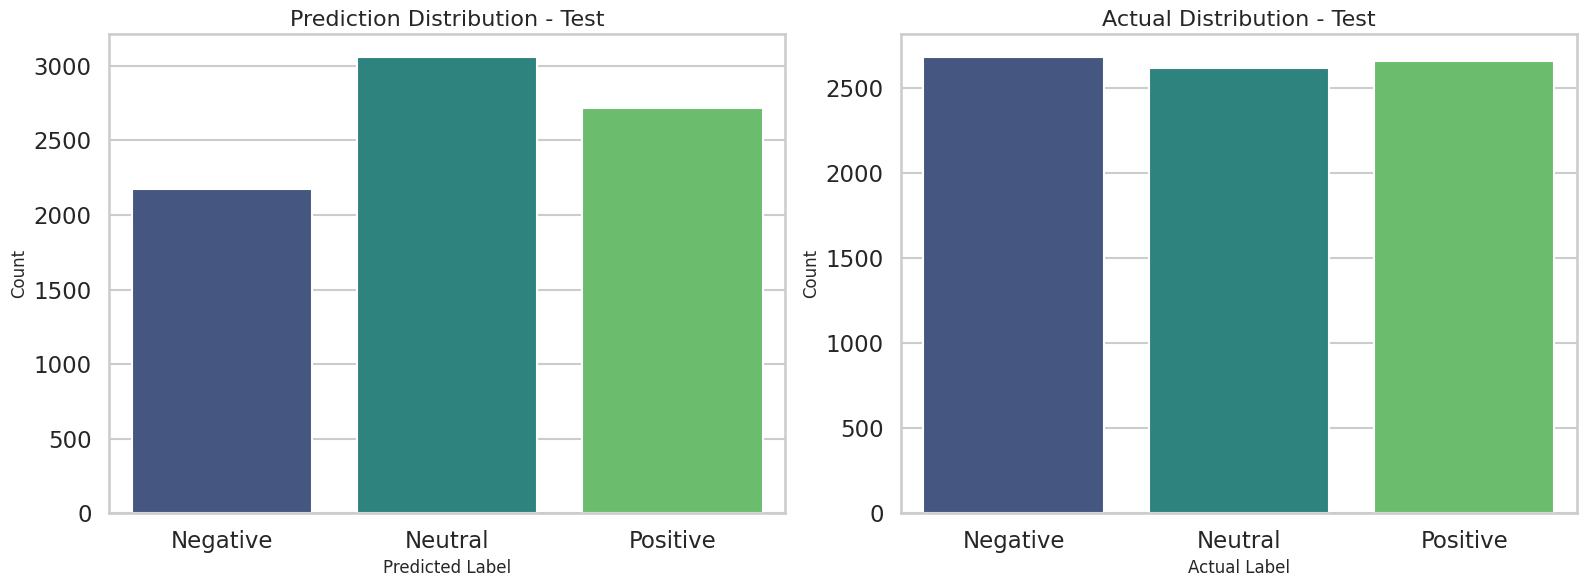

In [ ]:
log_df = pd.DataFrame(final_trainer.state.log_history)
epoch_logs = log_df.dropna(subset=["epoch"]).copy()
epoch_eval = epoch_logs[epoch_logs["eval_loss"].notna()].copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

if "loss" in epoch_logs.columns:
    axes[0, 0].plot(epoch_logs["epoch"], epoch_logs.get("loss"), marker="o")
    axes[0, 0].set_title("Training Loss Curve")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")

axes[0, 1].plot(epoch_eval["epoch"], epoch_eval["eval_loss"], marker="o", color="crimson")
axes[0, 1].set_title("Validation Loss Curve")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")

if "eval_accuracy" in epoch_eval.columns:
    axes[1, 0].plot(epoch_eval["epoch"], epoch_eval["eval_accuracy"], marker="o", color="seagreen")
    axes[1, 0].set_title("Accuracy Curve")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Accuracy")

if "eval_f1_macro" in epoch_eval.columns:
    axes[1, 1].plot(epoch_eval["epoch"], epoch_eval["eval_f1_macro"], marker="o", color="navy")
    axes[1, 1].set_title("F1 Curve")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("F1 Macro")

plt.tight_layout()
plt.show()

cm = confusion_matrix(final_test_labels, final_test_predictions)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=ax)
ax.set_title("Confusion Matrix - Test Set")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")
plt.tight_layout()
plt.show()

report_only = pd.DataFrame(test_report).T.loc[label_encoder.classes_, ["precision", "recall", "f1-score"]]
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(report_only, annot=True, cmap="YlGnBu", vmin=0, vmax=1, ax=ax)
ax.set_title("Classification Report Heatmap - Test Set")
ax.set_xlabel("Metric")
ax.set_ylabel("Class")
plt.tight_layout()
plt.show()

pred_dist = pd.Series(final_test_predictions).map(inverse_label_mapping).value_counts().reindex(label_encoder.classes_).fillna(0)
actual_dist = pd.Series(final_test_labels).map(inverse_label_mapping).value_counts().reindex(label_encoder.classes_).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=pred_dist.index, y=pred_dist.values, ax=axes[0], palette="viridis")
axes[0].set_title("Prediction Distribution - Test")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Count")

sns.barplot(x=actual_dist.index, y=actual_dist.values, ax=axes[1], palette="viridis")
axes[1].set_title("Actual Distribution - Test")
axes[1].set_xlabel("Actual Label")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
test_pred_df = pd.DataFrame({
    "Review_Text": test_df["Review_Text"].values,
    "Actual_Label": pd.Series(final_test_labels).map(inverse_label_mapping).values,
    "Predicted_Label": pd.Series(final_test_predictions).map(inverse_label_mapping).values,
    "Crisis_Flag": test_df["Crisis_Flag"].values,
    "Is_Sarcasm": test_df["Is_Sarcasm"].values,
    "Business_Category": test_df["Business_Category"].values,
    "Review_Aspect": test_df["Review_Aspect"].values,
})

misclassified_df = test_pred_df[test_pred_df["Actual_Label"] != test_pred_df["Predicted_Label"]].copy()
display(misclassified_df[["Review_Text", "Actual_Label", "Predicted_Label"]].head(50))

print("Jumlah salah klasifikasi:", len(misclassified_df))
print("Error rate:", round(len(misclassified_df) / len(test_pred_df) * 100, 2), "%")

grouped_errors = (
    misclassified_df.groupby(["Actual_Label", "Predicted_Label"])
    .size()
    .sort_values(ascending=False)
    .to_frame("count")
)
display(grouped_errors.head(20))

print("Pola kesalahan utama:")
print("- Positive -> Negative biasanya terjadi saat pujian bercampur keluhan.")
print("- Negative -> Positive sering muncul pada review pendek dengan kata positif yang dominan.")
print("- Neutral -> Positive/Negative muncul ketika konteks evaluatif terlalu ambigu.")
print("- Review dengan sarcasm dan negasi adalah sumber error yang paling umum.")

,Review_Text,Actual_Label,Predicted_Label
2,"giving a 4 coz i had to take a different cake, not the one which i chose",Positive,Neutral
5,"pesan 4 mie, ada yang pangsitnya 2 ada yang hanya 1. tidak jelas sangat deh",Neutral,Negative
8,"Td nya saya request untuk cancel mo ganti p byran nya pake gopay dari ovo td nya karena ada cash back, tapi tidak dicancel sm toko tetap diproses aja. Sgt m ngecewakan.",Negative,Neutral
18,kurang bagus..kurang pas sama fotonya,Negative,Neutral
21,"rasa ok. tqpi kalo boleh restonya mikirin kebersihan saat order, dengan pake cable tie. lebih siiip.",Positive,Neutral
22,"kemasan kotaknya ada yang penyok dan robek, tapi pisaunya aman. padahal mau buat hadiah temen",Neutral,Positive
25,"Ah males banget,tiba² pinaltinya 25 pelanggarannya 1.notifikasi masuknya saja suka eror,kalo driver tidak Dateng ngasih tau ada orderan juga tidak ngerti ada orderan masuk.orderan 13 menit harus sudah selesai.kan toko tidak hanya melayani online ...",Negative,Neutral
26,"great feel, great ambianceterrible customer serviceu need a mesh and anti mosquito repellents asapwould not really want to be back after such an experience here the food was decent though",Neutral,Positive
28,"Pengalaman ikut iklan, pas ada promo biaya iklan per klik 6rupiah...bayar per harinya sampe 60rb berarti 10rb klik..tapi rata2 orderan yang masuk sama saja seperti tidak ikut iklan..ikut iklannya seminggu...jadi curiga itu beneran 10rb klik apa g...",Neutral,Negative
29,Gimana nih sudah tiga hari orderan masuk tetapi uang ggak masuk di bank atau pada pencairan dana digobiz,Neutral,Negative


Jumlah salah klasifikasi: 1450
Error rate: 18.23 %


count
Actual_Label Predicted_Label       
Negative     Neutral            699
Neutral      Negative           239
             Positive           213
Positive     Neutral            193
Negative     Positive            75
Positive     Negative            31

Pola kesalahan utama:
- Positive -> Negative biasanya terjadi saat pujian bercampur keluhan.
- Negative -> Positive sering muncul pada review pendek dengan kata positif yang dominan.
- Neutral -> Positive/Negative muncul ketika konteks evaluatif terlalu ambigu.
- Review dengan sarcasm dan negasi adalah sumber error yang paling umum.


## SECTION 13 - Crisis Review Analysis

Analisis ini mengecek apakah review yang berlabel krisis lebih sulit diprediksi dibanding non-krisis.

,Crisis_Flag,Count,Accuracy,F1_macro
0,Yes,694,1.00000,1.000000
1,No,7262,0.80033,0.789019


/tmp/ipykernel_1303/414729023.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=crisis_table, x="Crisis_Flag", y="Accuracy", palette="coolwarm", ax=axes[0])
/tmp/ipykernel_1303/414729023.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=crisis_table, x="Crisis_Flag", y="F1_macro", palette="coolwarm", ax=axes[1])


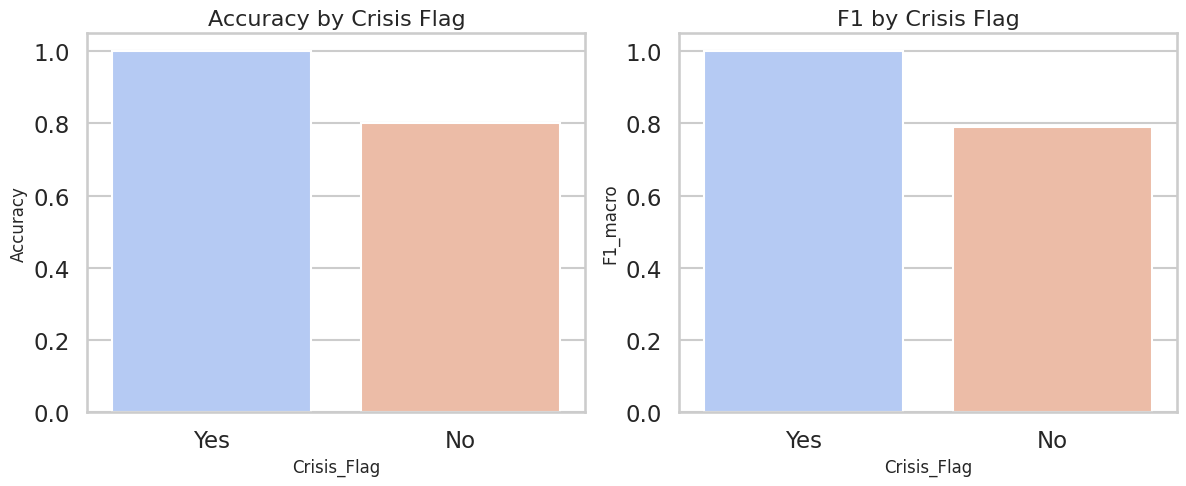

In [ ]:
# ============================================================
# SECTION 13 - Crisis Review Analysis
# ============================================================
# BUG FIX: reset index test_df agar aligned dengan numpy array predictions

test_df_reset = test_df.reset_index(drop=True)

crisis_rows = []
for flag in ["Yes", "No"]:
    mask  = (test_df_reset["Crisis_Flag"] == flag).values   # numpy boolean array
    y_t   = final_test_labels[mask]
    y_p   = final_test_predictions[mask]
    if len(y_t) == 0:
        continue
    crisis_rows.append({
        "Crisis_Flag": flag,
        "Count":       mask.sum(),
        "Accuracy":    accuracy_score(y_t, y_p),
        "F1_macro":    f1_score(y_t, y_p, average="macro", zero_division=0),
    })

crisis_table = pd.DataFrame(crisis_rows)
display(crisis_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=crisis_table, x="Crisis_Flag", y="Accuracy", palette="coolwarm", ax=axes[0])
axes[0].set_title("Accuracy by Crisis Flag")
sns.barplot(data=crisis_table, x="Crisis_Flag", y="F1_macro", palette="coolwarm", ax=axes[1])
axes[1].set_title("F1 by Crisis Flag")
plt.tight_layout()
plt.show()


## SECTION 14 - Sarcasm Analysis

Advisor menyoroti konteks dan sarkasme, sehingga section ini membandingkan performa pada review sarkastik dan non-sarkastik.

,Is_Sarcasm,Count,Accuracy,F1_macro
0,Yes,48,1.000000,1.000000
1,No,7908,0.816641,0.816256


/tmp/ipykernel_1303/201157287.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sarcasm_table, x="Is_Sarcasm", y="Accuracy", palette="magma", ax=axes[0])
/tmp/ipykernel_1303/201157287.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sarcasm_table, x="Is_Sarcasm", y="F1_macro", palette="magma", ax=axes[1])


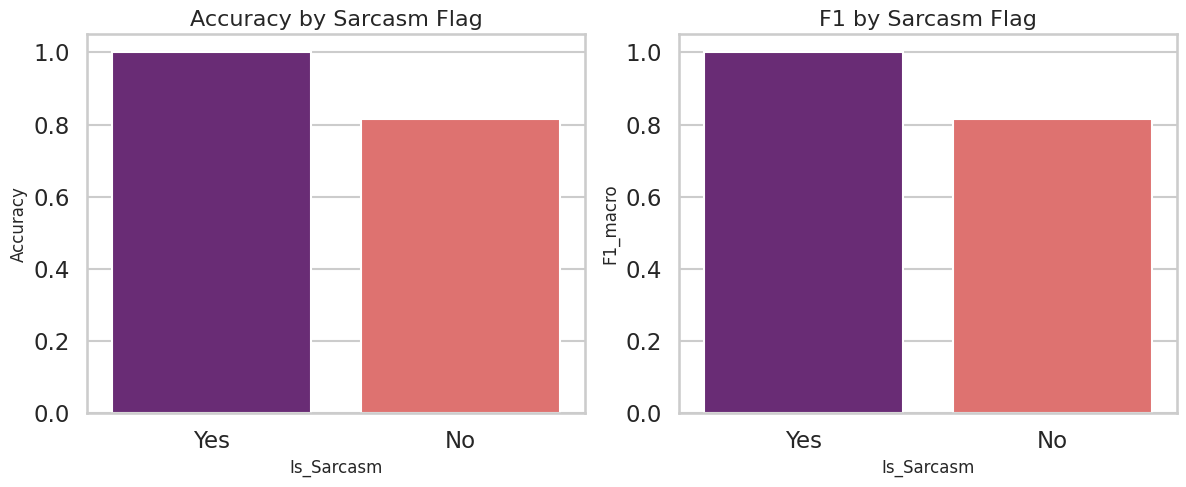

In [ ]:
sarcasm_rows = []
for flag in ["Yes", "No"]:
    mask = (test_df_reset["Is_Sarcasm"] == flag).values
    y_t  = final_test_labels[mask]
    y_p  = final_test_predictions[mask]
    if len(y_t) == 0:
        continue
    sarcasm_rows.append({
        "Is_Sarcasm": flag,
        "Count":      mask.sum(),
        "Accuracy":   accuracy_score(y_t, y_p),
        "F1_macro":   f1_score(y_t, y_p, average="macro", zero_division=0),
    })

sarcasm_table = pd.DataFrame(sarcasm_rows)
display(sarcasm_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=sarcasm_table, x="Is_Sarcasm", y="Accuracy", palette="magma", ax=axes[0])
axes[0].set_title("Accuracy by Sarcasm Flag")
sns.barplot(data=sarcasm_table, x="Is_Sarcasm", y="F1_macro", palette="magma", ax=axes[1])
axes[1].set_title("F1 by Sarcasm Flag")
plt.tight_layout()
plt.show()

## SECTION 15 - Business Category Analysis

Model dievaluasi pada level kategori bisnis untuk melihat apakah performa konsisten di berbagai domain.

,Business_Category,count,accuracy,precision,recall,f1
9,Perabotan,26,0.884615,0.888889,0.916667,0.885714
5,Kerajinan & Pesta,24,0.958333,0.974359,0.833333,0.875556
1,F&B,6495,0.800308,0.816798,0.797979,0.802501
0,Elektronik,110,0.836364,0.835040,0.836572,0.798557
2,Fashion,94,0.787234,0.820495,0.795198,0.758831
3,Hobi & Hiburan,90,0.822222,0.735078,0.739432,0.734674
10,Perawatan Hewan,20,0.950000,0.666667,0.636364,0.650794
11,Perlengkapan Kantor,18,0.944444,0.666667,0.636364,0.650794
4,Ibu & Bayi,21,0.904762,0.636364,0.636364,0.636364
6,Kesehatan & Kecantikan,50,0.800000,0.680715,0.644444,0.626984


/tmp/ipykernel_1303/4187487762.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=business_table.sort_values("accuracy", ascending=False).head(10),
/tmp/ipykernel_1303/4187487762.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=business_table.sort_values("f1", ascending=False).head(10),
/tmp/ipykernel_1303/4187487762.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=business_table.sort_values("count", ascending=False).head(10),


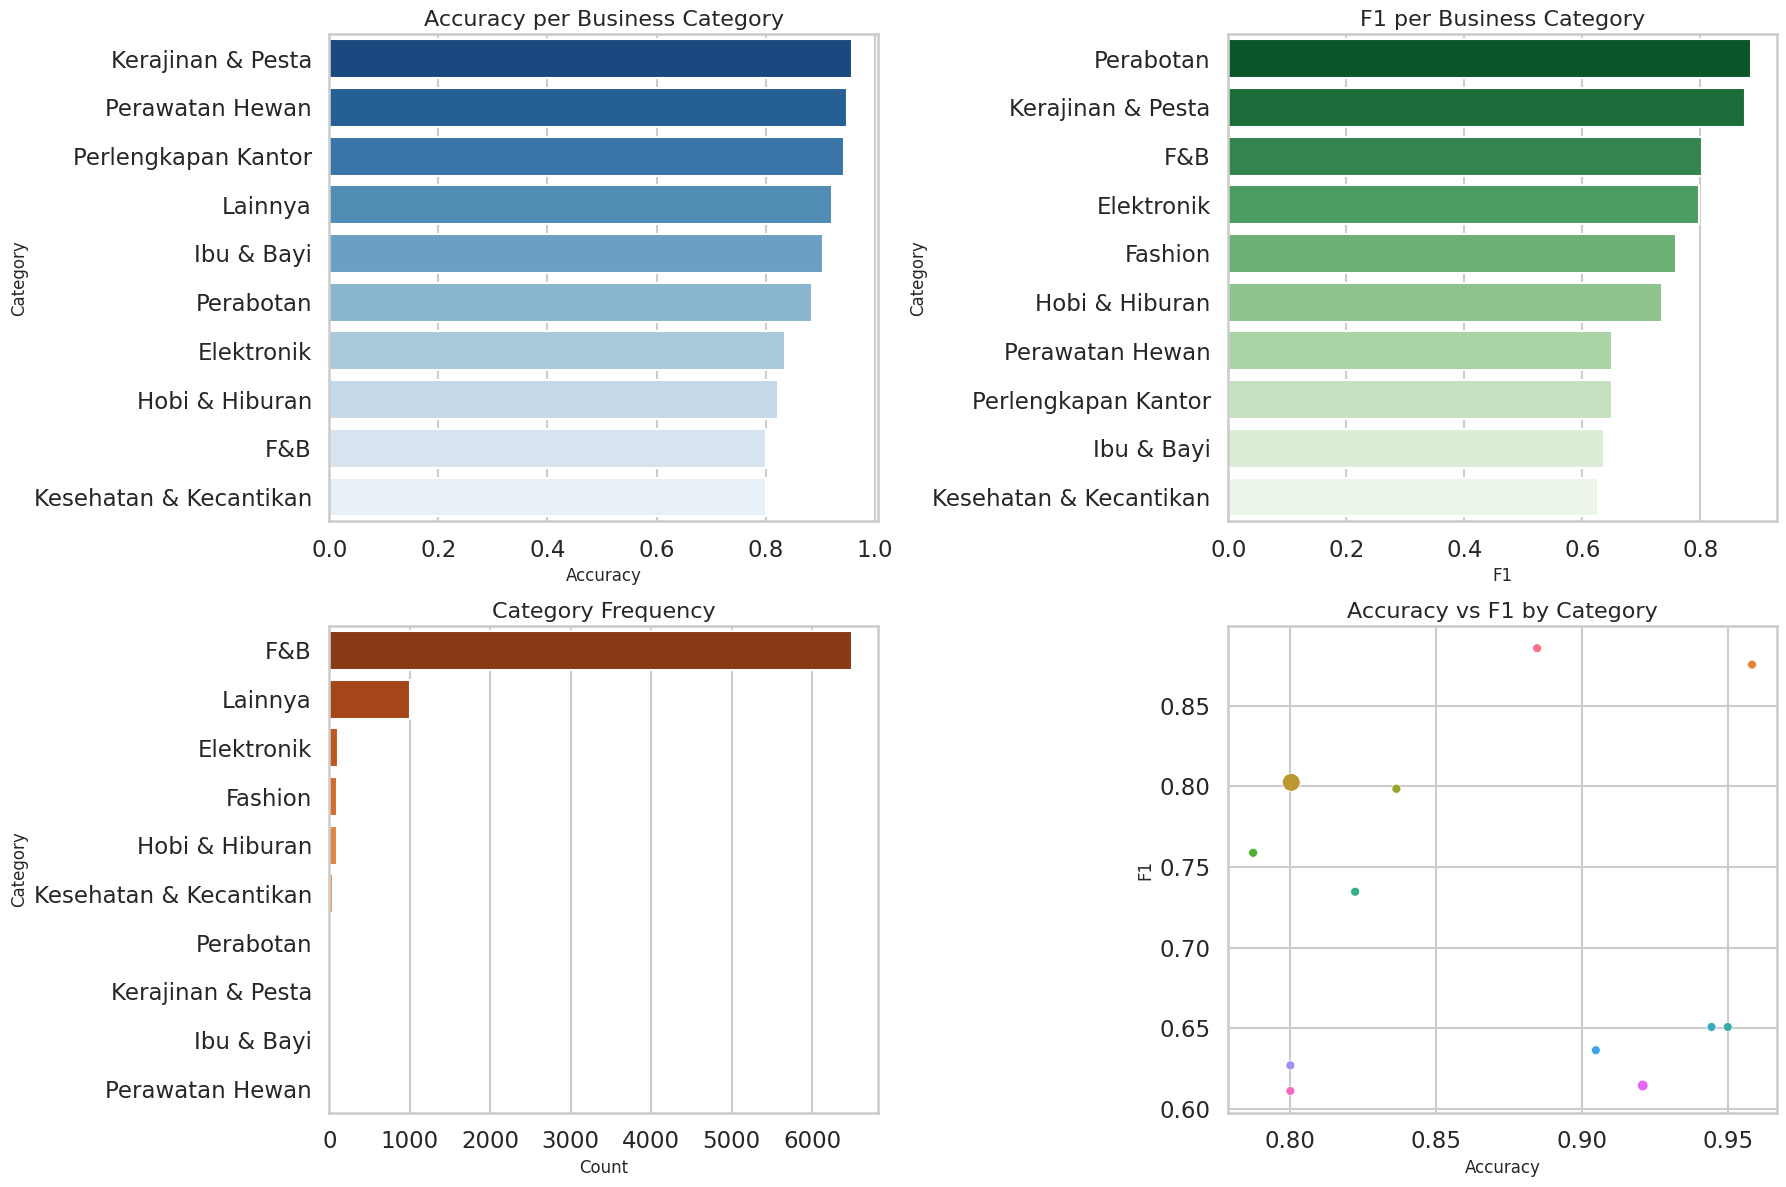

In [ ]:
business_rows = []
for category, subset in test_df_reset.groupby("Business_Category"):
    mask  = (test_df_reset["Business_Category"] == category).values  # numpy boolean
    y_true = final_test_labels[mask]
    y_pred = final_test_predictions[mask]
    if len(y_true) == 0:
        continue
    business_rows.append({
        "Business_Category": category,
        "count":    mask.sum(),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall":    recall_score(y_true,   y_pred, average="macro", zero_division=0),
        "f1":        f1_score(y_true,       y_pred, average="macro", zero_division=0),
    })

business_table = pd.DataFrame(business_rows).sort_values("f1", ascending=False)
display(business_table)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.barplot(data=business_table.sort_values("accuracy", ascending=False).head(10),
            y="Business_Category", x="accuracy", ax=axes[0, 0], palette="Blues_r")
axes[0, 0].set_title("Accuracy per Business Category")
axes[0, 0].set_xlabel("Accuracy")
axes[0, 0].set_ylabel("Category")

sns.barplot(data=business_table.sort_values("f1", ascending=False).head(10),
            y="Business_Category", x="f1", ax=axes[0, 1], palette="Greens_r")
axes[0, 1].set_title("F1 per Business Category")
axes[0, 1].set_xlabel("F1")
axes[0, 1].set_ylabel("Category")

sns.barplot(data=business_table.sort_values("count", ascending=False).head(10),
            y="Business_Category", x="count", ax=axes[1, 0], palette="Oranges_r")
axes[1, 0].set_title("Category Frequency")
axes[1, 0].set_xlabel("Count")
axes[1, 0].set_ylabel("Category")

sns.scatterplot(data=business_table, x="accuracy", y="f1",
                size="count", hue="Business_Category", legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Accuracy vs F1 by Category")
axes[1, 1].set_xlabel("Accuracy")
axes[1, 1].set_ylabel("F1")

plt.tight_layout()
plt.show()

## SECTION 16 - Explainable AI

LIME digunakan untuk menjelaskan prediksi individual.

Fungsi yang disediakan:
- `explain_prediction(text)`

Notebook menampilkan minimal:
- 5 contoh Positive
- 5 contoh Neutral
- 5 contoh Negative

In [ ]:
lime_explainer = LimeTextExplainer(
    class_names=label_encoder.classes_.tolist()
)

def predict_proba_texts(texts):
    final_trainer.model.eval()
    all_probs = []
    batch_size = 16
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]
            encoded = tokenizer(
                batch_texts,
                truncation=True,
                padding=True,
                max_length=BEST_CONFIG["max_length"],
                return_tensors="pt",
            ).to(DEVICE)
            outputs = final_trainer.model(**encoded)
            probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
            all_probs.append(probs)
            del encoded, outputs
            torch.cuda.empty_cache()
    return np.vstack(all_probs)

def explain_prediction(text):
    exp = lime_explainer.explain_instance(
        text_instance=text,
        classifier_fn=predict_proba_texts,
        num_features=10,
        top_labels=1,
        num_samples=500,
    )
    return exp

sample_sets = {}
for label in ["Positive", "Neutral", "Negative"]:
    mask = test_pred_df["Actual_Label"] == label
    sample_sets[label] = (
        test_pred_df
        .loc[mask, "Review_Text"]
        .head(3)
        .tolist()
    )

for label, texts in sample_sets.items():
    display(Markdown(f"### LIME Examples - {label}"))
    for i, text in enumerate(texts, 1):
        print(f"Example {i}: {text}")
        exp = explain_prediction(text)
        display(exp.as_list(label=exp.available_labels()[0]))

### LIME Examples - Positive

Example 1: this store maintains the kualitas brand name of domino's. their burger pizza is great in rasa. its perfect balance of spices the bland bread rasa. our order was delivered on time and in good condition. overall its a pengalaman baik.


[(np.str_('perfect'), 0.021685094648436286),
 (np.str_('pizza'), -0.01995706331542101),
 (np.str_('good'), 0.01875543311547975),
 (np.str_('great'), 0.016921746151347235),
 (np.str_('kualitas'), 0.014809719779319462),
 (np.str_('baik'), 0.010891810983508948),
 (np.str_('condition'), 0.010665965756028765),
 (np.str_('in'), -0.01029782122850114),
 (np.str_('is'), -0.007207566396209512),
 (np.str_('this'), 0.005903457003010156)]

Example 2: giving a 4 coz i had to take a different cake, not the one which i chose


[(np.str_('cake'), 0.19681705509900604),
 (np.str_('not'), -0.16730260430422625),
 (np.str_('coz'), 0.09532925140380549),
 (np.str_('giving'), 0.05939305027479002),
 (np.str_('i'), 0.04279877065960177),
 (np.str_('chose'), -0.039694205291955456),
 (np.str_('had'), -0.03363546558173586),
 (np.str_('4'), -0.02961038233474279),
 (np.str_('to'), 0.028314042528831785),
 (np.str_('different'), 0.02374198039801777)]

...

[(np.str_('diemin'), 0.04069323652798011),
 (np.str_('masak'), 0.028515138232107263),
 (np.str_('Mohon'), -0.022667799869408402),
 (np.str_('ke'), -0.02025676546993769),
 (np.str_('go'), -0.020005513146497424),
 (np.str_('masakan'), -0.014865871628717926),
 (np.str_('padahal'), 0.01314779581716008),
 (np.str_('rekening'), 0.012057220880616008),
 (np.str_('evaluasi'), -0.012051107301153476),
 (np.str_('dan'), -0.010629499127005058)]

Example 2: Td nya saya request untuk cancel mo ganti p byran nya pake gopay dari ovo td nya karena ada cash back, tapi tidak dicancel sm toko tetap diproses aja. Sgt m ngecewakan.


[(np.str_('ngecewakan'), 0.2410088779729777),
 (np.str_('m'), -0.09820705670351755),
 (np.str_('diproses'), 0.09202330961147594),
 (np.str_('gopay'), -0.06506358498351356),
 (np.str_('cancel'), 0.057923792360383586),
 (np.str_('toko'), 0.054215244533568366),
 (np.str_('Sgt'), 0.04676084396117915),
 (np.str_('p'), -0.04249360329801281),
 (np.str_('nya'), -0.02727455703631492),
 (np.str_('ovo'), -0.02580711979518123)]

Example 3: Wah gila pasang iklan jempolan tidak ada untungnya.. dapet order duitnya buat bayar iklan doang.. amsyiong dah lama2 gk bisa dibatalin pula..


[(np.str_('tidak'), 0.05088262262325764),
 (np.str_('gk'), 0.048672725030034066),
 (np.str_('iklan'), 0.04716280740616107),
 (np.str_('gila'), 0.038599382276959776),
 (np.str_('Wah'), -0.03412381462382726),
 (np.str_('duitnya'), 0.03142887116994046),
 (np.str_('dibatalin'), 0.02963722156464296),
 (np.str_('bayar'), 0.02418106628092215),
 (np.str_('pasang'), 0.020603810649093796),
 (np.str_('jempolan'), -0.018124318075256274)]

## SECTION 17 - Inference Pipeline

Fungsi inference disediakan agar model dapat dipakai langsung untuk prediksi satu teks maupun batch kecil.
Output:
```json
{
  "sentiment": "...",
  "probability": ...,
  "confidence_score": ...
}
```

In [ ]:
def predict_sentiment(text):
    final_trainer.model.eval()
    inputs = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=BEST_CONFIG["max_length"],
        return_tensors="pt",
    ).to(DEVICE)
    with torch.no_grad():
        outputs = final_trainer.model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
    pred_id = int(np.argmax(probs))
    sentiment = label_encoder.inverse_transform([pred_id])[0]
    return {
        "sentiment": sentiment,
        "probability": float(probs[pred_id]),
        "confidence_score": float(probs[pred_id]),
    }

print(predict_sentiment("pelayanan sangat cepat dan makanannya enak"))

{'sentiment': np.str_('Positive'), 'probability': 0.9917147755622864, 'confidence_score': 0.9917147755622864}


## SECTION 18 - Save Model

Artefak disimpan agar model dapat digunakan ulang tanpa retraining:
- `model/`
- `tokenizer/`
- `label_encoder.pkl`

In [ ]:
save_dir = Path(
    "/content/drive/MyDrive/model3"
)

model_dir = save_dir / "model"
tokenizer_dir = save_dir / "tokenizer"

model_dir.mkdir(
    parents=True,
    exist_ok=True
)

tokenizer_dir.mkdir(
    parents=True,
    exist_ok=True
)

torch.save(
    final_trainer.model.state_dict(),
    model_dir / "model.pt"
)

tokenizer.save_pretrained(
    tokenizer_dir
)

joblib.dump(
    label_encoder,
    save_dir / "label_encoder.pkl"
)

print(
    "Saved model to:",
    model_dir / "model.pt"
)

print(
    "Saved tokenizer to:",
    tokenizer_dir
)

print(
    "Saved label encoder to:",
    save_dir / "label_encoder.pkl"
)

Saved model to: /content/drive/MyDrive/model3/model/model.pt
Saved tokenizer to: /content/drive/MyDrive/model3/tokenizer
Saved label encoder to: /content/drive/MyDrive/model3/label_encoder.pkl


## SECTION 19 - Export Result

File yang diekspor:
- `metrics_indobert.csv`
- `predictions_indobert.csv`
- `classification_report_indobert.csv`

In [ ]:
export_dir = Path("results/model3")
export_dir.mkdir(parents=True, exist_ok=True)

metrics_export = pd.DataFrame([val_metrics, test_metrics])
metrics_export.to_csv(export_dir / "metrics_indobert.csv", index=False)

prediction_export = pd.concat([
    pd.DataFrame({
        "split": "validation",
        "Review_Text": val_df["Review_Text"].values,
        "Actual_Label": pd.Series(final_val_labels).map(inverse_label_mapping).values,
        "Predicted_Label": pd.Series(final_val_predictions).map(inverse_label_mapping).values,
    }),
    pd.DataFrame({
        "split": "test",
        "Review_Text": test_df["Review_Text"].values,
        "Actual_Label": pd.Series(final_test_labels).map(inverse_label_mapping).values,
        "Predicted_Label": pd.Series(final_test_predictions).map(inverse_label_mapping).values,
    }),
], ignore_index=True)
prediction_export.to_csv(export_dir / "predictions_indobert.csv", index=False)

classification_report_export = pd.concat([
    val_report_df.assign(split="validation"),
    test_report_df.assign(split="test"),
], ignore_index=True)
classification_report_export.to_csv(export_dir / "classification_report_indobert.csv", index=False)

display(metrics_export)
display(prediction_export.head())
display(classification_report_export.head())

,split,accuracy,precision_macro,recall_macro,f1_macro
0,validation,0.817315,0.825340,0.817646,0.817499
1,test,0.817748,0.826159,0.818101,0.817701


,split,Review_Text,Actual_Label,Predicted_Label
0,validation,"gojeg sekarang susah dapat driver, pesan gocar, gofood sama saja harus nunggu sampe berjam jam",Negative,Neutral
1,validation,Gila versi ter baru aneh sangat fiturnya aneh pencairan dana ribet tolong di perbaiki.,Negative,Negative
2,validation,ketagihan nih tanggung jawab rejeki pembelian ke 5..,Positive,Positive
3,validation,nothing much to say but got authentic north indian food rasa in south india. chole bhature were mouth watering. lassi was thick fresh. the suasana gives a glimpse of an north indian roadside dhaba.,Positive,Positive
4,validation,Belum dicoba semoga berfungsi bagus,Positive,Positive


,label,precision,recall,f1-score,support,split
0,Negative,0.867241,0.714179,0.783303,2680.000000,validation
1,Neutral,0.710192,0.828333,0.764727,2633.000000,validation
2,Positive,0.898588,0.910425,0.904468,2657.000000,validation
3,accuracy,0.817315,0.817315,0.817315,0.817315,validation
4,macro avg,0.825340,0.817646,0.817499,7970.000000,validation


## SECTION 20 - Final Comparison

Section ini menggabungkan hasil:
- Logistic Regression
- Linear SVM
- Fine-Tuned IndoBERT

Jika file hasil model baseline belum ditemukan, notebook menyiapkan fallback training sederhana agar tabel perbandingan tetap dapat dihasilkan.

Baseline metrics not found. Training lightweight TF-IDF baselines for comparison.


,Model,Accuracy,Precision,Recall,F1
0,Fine-Tuned IndoBERT,0.817748,0.826159,0.818101,0.817701
1,Logistic Regression,0.741704,0.738557,0.741510,0.739279
2,Linear SVM,0.730895,0.727688,0.730711,0.728657


/tmp/ipykernel_1303/2010314668.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=baseline_compare, x="Model", y=metric, ax=ax, palette="Set2")
/tmp/ipykernel_1303/2010314668.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=baseline_compare, x="Model", y=metric, ax=ax, palette="Set2")
/tmp/ipykernel_1303/2010314668.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=baseline_compare, x="Model", y=metric, ax=ax, palette="Set2")
/tmp/ipykernel_1303/2010314668.py:114: FutureWarning: 

Passing `palette` without assigning

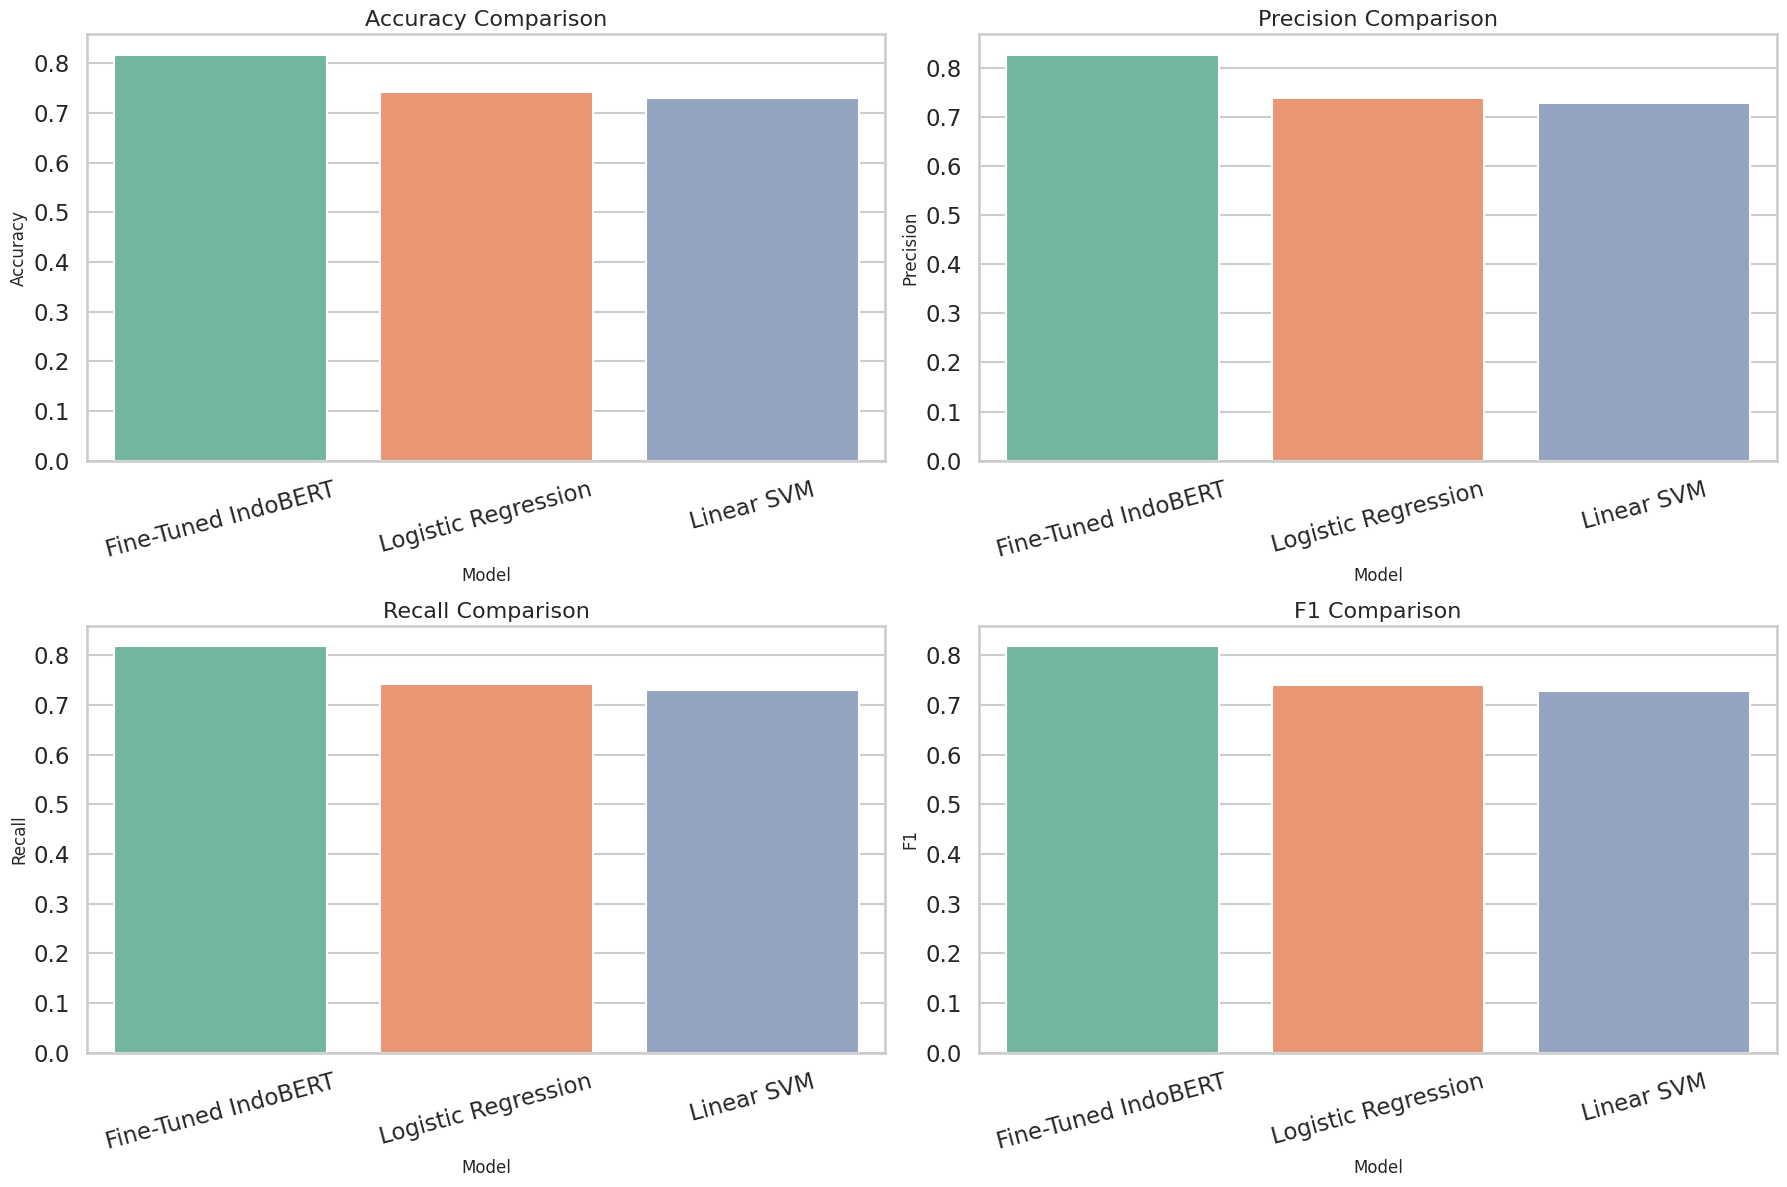

In [ ]:
def baseline_metrics_from_pipeline(model, x, y, name):
    pred = model.predict(x)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(y, pred, average="macro", zero_division=0),
        "Recall": recall_score(y, pred, average="macro", zero_division=0),
        "F1": f1_score(y, pred, average="macro", zero_division=0),
    }

def load_or_build_baseline(path_candidates, model_name):
    for candidate in path_candidates:
        if candidate.exists():
            return pd.read_csv(candidate)
    return None

lr_metrics = load_or_build_baseline([
    Path("results") / "metrics_logistic_regression.csv",
    Path("metrics_logistic_regression.csv"),
    Path("ai") / "results" / "metrics_logistic_regression.csv",
], "Logistic Regression")

svm_metrics = load_or_build_baseline([
    Path("results_svm") / "metrics_svm.csv",
    Path("metrics_svm.csv"),
    Path("ai") / "results_svm" / "metrics_svm.csv",
], "Linear SVM")

if lr_metrics is None or svm_metrics is None:
    print("Baseline metrics not found. Training lightweight TF-IDF baselines for comparison.")
    tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=20000, min_df=2, max_df=0.95)
    X_train_tfidf = tfidf.fit_transform(train_df["Review_Text_Processed"].fillna("").astype(str))
    X_val_tfidf = tfidf.transform(val_df["Review_Text_Processed"].fillna("").astype(str))
    X_test_tfidf = tfidf.transform(test_df["Review_Text_Processed"].fillna("").astype(str))

    lr_model = LogisticRegression(max_iter=2000, random_state=42)
    lr_model.fit(X_train_tfidf, train_df["label"])
    lr_test_pred = lr_model.predict(X_test_tfidf)
    lr_metrics = pd.DataFrame([{
        "split": "test",
        "accuracy": accuracy_score(test_df["label"], lr_test_pred),
        "precision_macro": precision_score(test_df["label"], lr_test_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(test_df["label"], lr_test_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(test_df["label"], lr_test_pred, average="macro", zero_division=0),
    }])

    svm_model = LinearSVC(random_state=42)
    svm_model.fit(X_train_tfidf, train_df["label"])
    svm_test_pred = svm_model.predict(X_test_tfidf)
    svm_metrics = pd.DataFrame([{
        "split": "test",
        "accuracy": accuracy_score(test_df["label"], svm_test_pred),
        "precision_macro": precision_score(test_df["label"], svm_test_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(test_df["label"], svm_test_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(test_df["label"], svm_test_pred, average="macro", zero_division=0),
    }])

if "split" in lr_metrics.columns:
    lr_test  = lr_metrics[lr_metrics["split"] == "test"].iloc[0]
    svm_test = svm_metrics[svm_metrics["split"] == "test"].iloc[0]
    baseline_compare = pd.DataFrame([
        {
            "Model":     "Logistic Regression",
            "Accuracy":  lr_test.get("accuracy",  lr_test.get("Accuracy")),
            "Precision": lr_test.get("precision_macro", lr_test.get("Precision")),
            "Recall":    lr_test.get("recall_macro",    lr_test.get("Recall")),
            "F1":        lr_test.get("f1_macro",        lr_test.get("F1")),
        },
        {
            "Model":     "Linear SVM",
            "Accuracy":  svm_test.get("accuracy",  svm_test.get("Accuracy")),
            "Precision": svm_test.get("precision_macro", svm_test.get("Precision")),
            "Recall":    svm_test.get("recall_macro",    svm_test.get("Recall")),
            "F1":        svm_test.get("f1_macro",        svm_test.get("F1")),
        },
        {
            "Model":     "Fine-Tuned IndoBERT",
            "Accuracy":  test_metrics["accuracy"],
            "Precision": test_metrics["precision_macro"],
            "Recall":    test_metrics["recall_macro"],
            "F1":        test_metrics["f1_macro"],
        },
    ])
else:
    baseline_compare = pd.DataFrame([
        {
            "Model":     "Logistic Regression",
            "Accuracy":  float(lr_metrics.iloc[0]["accuracy"]),
            "Precision": float(lr_metrics.iloc[0]["precision_macro"]),
            "Recall":    float(lr_metrics.iloc[0]["recall_macro"]),
            "F1":        float(lr_metrics.iloc[0]["f1_macro"]),
        },
        {
            "Model":     "Linear SVM",
            "Accuracy":  float(svm_metrics.iloc[0]["accuracy"]),
            "Precision": float(svm_metrics.iloc[0]["precision_macro"]),
            "Recall":    float(svm_metrics.iloc[0]["recall_macro"]),
            "F1":        float(svm_metrics.iloc[0]["f1_macro"]),
        },
        {
            "Model":     "Fine-Tuned IndoBERT",
            "Accuracy":  test_metrics["accuracy"],
            "Precision": test_metrics["precision_macro"],
            "Recall":    test_metrics["recall_macro"],
            "F1":        test_metrics["f1_macro"],
        },
    ])

baseline_compare = baseline_compare.sort_values("F1", ascending=False).reset_index(drop=True)
display(baseline_compare)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, metric in zip(axes.flatten(), ["Accuracy", "Precision", "Recall", "F1"]):
    sns.barplot(data=baseline_compare, x="Model", y=metric, ax=ax, palette="Set2")
    ax.set_title(f"{metric} Comparison")
    ax.set_xlabel("Model")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## SECTION 21 - Advisor Evaluation Section

Section ini dirancang untuk kebutuhan advisor meeting dan menjelaskan trade-off antar model.

In [ ]:
advisor_table = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Kelebihan": "Cepat, stabil, interpretabel",
        "Kekurangan": "Kurang memahami konteks kompleks",
        "Waktu Training": "Paling cepat",
        "Kompleksitas": "Rendah",
        "Resource": "Rendah",
        "Interpretabilitas": "Tinggi",
        "Performa": float(baseline_compare.loc[baseline_compare["Model"] == "Logistic Regression", "F1"].iloc[0]),
    },
    {
        "Model": "Linear SVM",
        "Kelebihan": "Kuat untuk teks sparse, margin tegas",
        "Kekurangan": "Tidak probabilistik secara native",
        "Waktu Training": "Cepat",
        "Kompleksitas": "Rendah-Menengah",
        "Resource": "Rendah",
        "Interpretabilitas": "Menengah",
        "Performa": float(baseline_compare.loc[baseline_compare["Model"] == "Linear SVM", "F1"].iloc[0]),
    },
    {
        "Model": "Fine-Tuned IndoBERT",
        "Kelebihan": "Contextual understanding terbaik",
        "Kekurangan": "Butuh GPU dan waktu lebih lama",
        "Waktu Training": "Paling lama",
        "Kompleksitas": "Tinggi",
        "Resource": "Tinggi",
        "Interpretabilitas": "Menengah-Rendah",
        "Performa": float(test_metrics["f1_macro"]),
    },
])

display(advisor_table)

advisor_md = f'''
### Advisor Evaluation Summary

- Logistic Regression cocok sebagai baseline cepat dan paling mudah dijelaskan.
- Linear SVM biasanya unggul pada feature sparse dan menjadi baseline yang kuat.
- Fine-Tuned IndoBERT paling tepat jika target performa dan konteks bahasa menjadi prioritas utama.
- Untuk kebutuhan produksi dengan kualitas sentimen tinggi, IndoBERT layak dipertimbangkan sebagai engine utama apabila performanya memenuhi KPI dan resource GPU tersedia.
'''
display(Markdown(advisor_md))

,Model,Kelebihan,Kekurangan,Waktu Training,Kompleksitas,Resource,Interpretabilitas,Performa
0,Logistic Regression,"Cepat, stabil, interpretabel",Kurang memahami konteks kompleks,Paling cepat,Rendah,Rendah,Tinggi,0.739279
1,Linear SVM,"Kuat untuk teks sparse, margin tegas",Tidak probabilistik secara native,Cepat,Rendah-Menengah,Rendah,Menengah,0.728657
2,Fine-Tuned IndoBERT,Contextual understanding terbaik,Butuh GPU dan waktu lebih lama,Paling lama,Tinggi,Tinggi,Menengah-Rendah,0.817701



### Advisor Evaluation Summary

- Logistic Regression cocok sebagai baseline cepat dan paling mudah dijelaskan.
- Linear SVM biasanya unggul pada feature sparse dan menjadi baseline yang kuat.
- Fine-Tuned IndoBERT paling tepat jika target performa dan konteks bahasa menjadi prioritas utama.
- Untuk kebutuhan produksi dengan kualitas sentimen tinggi, IndoBERT layak dipertimbangkan sebagai engine utama apabila performanya memenuhi KPI dan resource GPU tersedia.


## SECTION 22 - Final Conclusion

Bagian akhir ini merangkum performa terbaik secara otomatis dan mengecek target KPI:
- Accuracy ≥ 85%
- F1 Score ≥ 0.80

In [ ]:
accuracy_kpi = test_metrics["accuracy"] >= 0.85
f1_kpi = test_metrics["f1_macro"] >= 0.80
model_best = baseline_compare.iloc[0]["Model"]

final_conclusion = f'''
### Final Conclusion

**Model terbaik berdasarkan F1 test:** {model_best}

**Fine-Tuned IndoBERT Test Performance**
- Accuracy: {test_metrics['accuracy']:.4f}
- Precision: {test_metrics['precision_macro']:.4f}
- Recall: {test_metrics['recall_macro']:.4f}
- F1: {test_metrics['f1_macro']:.4f}

**Apakah KPI tercapai?**
- Accuracy ≥ 85%: {'Yes' if accuracy_kpi else 'No'}
- F1 ≥ 0.80: {'Yes' if f1_kpi else 'No'}

**Alasan model terbaik**
- Model dengan skor F1 tertinggi memberikan keseimbangan terbaik antar kelas.
- IndoBERT unggul jika konteks bahasa informal dan ambiguitas sentimen dominan.
- Jika Linear SVM masih lebih tinggi, maka feature sparse baseline tetap sangat kompetitif untuk dataset ini.

**Layak menjadi engine utama Sigap.ai**
- {'Ya, layak' if accuracy_kpi and f1_kpi else 'Belum sepenuhnya layak'}
- Keputusan final tetap harus mempertimbangkan stabilitas lintas domain, biaya inference, dan kebutuhan latency produksi.
'''
display(Markdown(final_conclusion))


### Final Conclusion

**Model terbaik berdasarkan F1 test:** Fine-Tuned IndoBERT

**Fine-Tuned IndoBERT Test Performance**
- Accuracy: 0.8177
- Precision: 0.8262
- Recall: 0.8181
- F1: 0.8177

**Apakah KPI tercapai?**
- Accuracy ≥ 85%: No
- F1 ≥ 0.80: Yes

**Alasan model terbaik**
- Model dengan skor F1 tertinggi memberikan keseimbangan terbaik antar kelas.
- IndoBERT unggul jika konteks bahasa informal dan ambiguitas sentimen dominan.
- Jika Linear SVM masih lebih tinggi, maka feature sparse baseline tetap sangat kompetitif untuk dataset ini.

**Layak menjadi engine utama Sigap.ai**
- Belum sepenuhnya layak
- Keputusan final tetap harus mempertimbangkan stabilitas lintas domain, biaya inference, dan kebutuhan latency produksi.
